#**Tecnicatura Universitaria en Gestión y Análisis de Datos en Organizaciones — FCE UBA**
###Trabajo Práctico Grupal · 1er Cuatrimestre 2026

---


**Repositorio:** [Link a Github](https://github.com/nicotucci/TP-Laboratorio-AnalisisFutbol)



------------------------

#INICIO
Antes de comenzar con el analisis puro, de antemano haremos una observacion para justificar la eleccion del mismo

In [1]:
import pandas as pd
archivo = "https://raw.githubusercontent.com/nicotucci/TP-Laboratorio-AnalisisFutbol/main/Datasets/gastos%20en%20transf%20por%20liga%20-%20Sheet1.csv"
df = pd.read_csv(archivo)
display(df.head(8))

,#,Competición,País,Gastos_EUR,Altas,Ingresos_EUR,Bajas,Balance_EUR
0,1,Premier League,Inglaterra,13040000000,1578,6880000000,1578,-6159210000
1,2,Serie A,Italia,4870000000,3063,4430000000,2990,-447250000
2,3,Ligue 1,Francia,3610000000,1475,3990000000,1648,381500000
3,4,Bundesliga,Alemania,3220000000,1299,3530000000,1358,311570000
4,5,LaLiga,España,2550000000,1361,2660000000,1493,108780000
5,6,Saudi Pro League,Arabia Saudita,2410000000,1417,419380000,1608,-1994850000
6,7,Campeonato Brasileiro Série A,Brasil,1470000000,2356,1750000000,2668,272070000
7,8,Liga Portugal,Portugal,1220000000,1606,2160000000,1709,943280000


**A partir de la observacion de esta tabla que muestra los movimientos numericos en fichajes de las principales ligas, notamos que la Premier League presenta el mayor desembolso economico del mercado de pases, lo que la convierte en un caso de estudio relevante para analizar la relacion entre inversion y rendimiento.**

## 0. Configuración del entorno e Importacion de Librerias
> El notebook **carga la base directamente desde el repositorio de GitHub del grupo** (no hace falta
> subir nada a mano)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import re

# Para mostrar mejor los gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
url_posiciones = 'https://raw.githubusercontent.com/nicotucci/TP-Laboratorio-AnalisisFutbol/96a19b6bbce85288569fd91373c350642ec96c57/Datasets/premier%20posiciones%2022-23%20-%20premier%20posiciones%2022-23.xlsx%20(1).csv'
posiciones = pd.read_csv(url_posiciones)

print("Posiciones:")
display(posiciones.head(5))
display(posiciones.tail(5))


Posiciones:


,#,Club,PJ,PG,PE,PP,GF,GC,DG,Pts
0,1,Manchester City,38,28,5,5,94,33,61,89
1,2,Arsenal FC,38,26,6,6,88,43,45,84
2,3,Manchester United,38,23,6,9,58,43,15,75
3,4,Newcastle United,38,19,14,5,68,33,35,71
4,5,Liverpool FC,38,19,10,9,75,47,28,67


,#,Club,PJ,PG,PE,PP,GF,GC,DG,Pts
15,16,Nottingham Forest,38,9,11,18,38,68,-30,38
16,17,Everton FC,38,8,12,18,34,57,-23,36
17,18,Leicester City,38,9,7,22,51,68,-17,34
18,19,Leeds United,38,7,10,21,48,78,-30,31
19,20,Southampton FC,38,6,7,25,36,73,-37,25


In [4]:
posiciones.dtypes


,0
#,int64
Club,object
PJ,int64
PG,int64
PE,int64
PP,int64
GF,int64
GC,int64
DG,int64
Pts,int64


In [5]:
url_transfers = 'https://raw.githubusercontent.com/nicotucci/TP-Laboratorio-AnalisisFutbol/375751256a1c519d570caec12bbfde865f0a4a39/Datasets/transferencias_2022_2022.csv'
transfers = pd.read_csv(url_transfers)
print("Transferencias:")
display(transfers.head(7))
display(transfers.tail(7))

Transferencias:


,club_name,player_name,age,position,club_involved_name,fee,transfer_movement,transfer_period,fee_cleaned,league_name,year,season,country
0,Arsenal FC,Gabriel Jesus,25.0,Centre-Forward,Man City,€52.20m,in,Summer,52.20,Premier League,2022,2022/2023,England
1,Arsenal FC,Oleksandr Zinchenko,25.0,Left-Back,Man City,€35.00m,in,Summer,35.00,Premier League,2022,2022/2023,England
2,Arsenal FC,Fábio Vieira,22.0,Attacking Midfield,FC Porto,€35.00m,in,Summer,35.00,Premier League,2022,2022/2023,England
3,Arsenal FC,Matt Turner,28.0,Goalkeeper,New England,€6.36m,in,Summer,6.36,Premier League,2022,2022/2023,England
4,Arsenal FC,Marquinhos,19.0,Right Winger,São Paulo,€3.50m,in,Summer,3.50,Premier League,2022,2022/2023,England
5,Arsenal FC,Konstantinos Mavropanos,24.0,Centre-Back,VfB Stuttgart,"End of loanJun 30, 2022",in,Summer,NaN,Premier League,2022,2022/2023,England
6,Arsenal FC,Auston Trusty,23.0,Centre-Back,Colorado,"End of loanJul 14, 2022",in,Summer,NaN,Premier League,2022,2022/2023,England


,club_name,player_name,age,position,club_involved_name,fee,transfer_movement,transfer_period,fee_cleaned,league_name,year,season,country
693,Wolverhampton Wanderers,Connor Ronan,24.0,Central Midfield,Colorado,€570k,out,Winter,0.57,Premier League,2022,2022/2023,England
694,Wolverhampton Wanderers,Léo Bonatini,28.0,Centre-Forward,San Luis,free transfer,out,Winter,0.00,Premier League,2022,2022/2023,England
695,Wolverhampton Wanderers,Fábio Silva,20.0,Centre-Forward,PSV Eindhoven,loan transfer,out,Winter,NaN,Premier League,2022,2022/2023,England
696,Wolverhampton Wanderers,Yerson Mosquera,21.0,Centre-Back,Cincinnati,loan transfer,out,Winter,NaN,Premier League,2022,2022/2023,England
697,Wolverhampton Wanderers,Ki-Jana Hoever,21.0,Right-Back,Stoke City,loan transfer,out,Winter,NaN,Premier League,2022,2022/2023,England
698,Wolverhampton Wanderers,Gonçalo Guedes,26.0,Second Striker,Benfica,loan transfer,out,Winter,NaN,Premier League,2022,2022/2023,England
699,Wolverhampton Wanderers,Matija Sarkic,25.0,Goalkeeper,Stoke City,loan transfer,out,Winter,NaN,Premier League,2022,2022/2023,England


In [6]:
transfers.dtypes

,0
club_name,object
player_name,object
age,float64
position,object
club_involved_name,object
fee,object
transfer_movement,object
transfer_period,object
fee_cleaned,float64
league_name,object


In [7]:
# Celda 3: Exploración inicial
print("Dimensiones posiciones:", posiciones.shape[0],"filas y",posiciones.shape[1],"columnas")
print("")
print("Nulos posiciones:\n", posiciones.isnull().sum())
print("\nEstadísticas posiciones:")
display(posiciones.describe())

Dimensiones posiciones: 20 filas y 10 columnas

Nulos posiciones:
 #       0
Club    0
PJ      0
PG      0
PE      0
PP      0
GF      0
GC      0
DG      0
Pts     0
dtype: int64

Estadísticas posiciones:


,#,PJ,PG,PE,PP,GF,GC,DG,Pts
count,20.00000,20.0,20.000000,20.00000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,10.50000,38.0,14.650000,8.70000,14.650000,54.200000,54.200000,0.000000,52.650000
std,5.91608,0.0,6.310184,2.81163,5.993637,18.429382,12.775799,27.877552,18.189861
min,1.00000,38.0,6.000000,5.00000,5.000000,31.000000,33.000000,-37.000000,25.000000
25%,5.75000,38.0,10.500000,6.75000,9.000000,38.000000,46.000000,-24.000000,38.750000
50%,10.50000,38.0,13.000000,7.50000,15.500000,51.000000,53.000000,-3.500000,48.500000
75%,15.25000,38.0,18.250000,11.00000,19.250000,68.500000,64.250000,16.000000,63.250000
max,20.00000,38.0,28.000000,14.00000,25.000000,94.000000,78.000000,61.000000,89.000000


**Notamos que hay 399 valores nulos en la tabla de transferencias que vienen de la columna fee_cleaned (tarifa limpia). esto se debe a que son casos en los que son "loan transfer" o casos donde llegan porque se les finalizo el contrato**





In [8]:
print("\nDimensiones transfers:", transfers.shape[0],"filas y",transfers.shape[1],"columnas")
print("")
print("Nulos transfers:\n", transfers.isnull().sum())


Dimensiones transfers: 700 filas y 13 columnas

Nulos transfers:
 club_name               0
player_name             0
age                     0
position                0
club_involved_name      0
fee                     0
transfer_movement       0
transfer_period         0
fee_cleaned           399
league_name             0
year                    0
season                  0
country                 0
dtype: int64


---------

# ❓ Pregunta principal
## ✅ **¿Existe una correlacion estadisticamente significativa entre el gasto neto en transferencias y la posicion final en la tabla de la Premier League?**

### Subpreguntas q se pueden agregar:

- ¿El gasto neto explica diferencias en posición final o hay outliers que desafían esa relación?

- ¿Cómo se compara la eficiencia de gasto entre clubes que gastaron mucho vs clubes con gasto neto negativo (vendieron más de lo que compraron)?

- ¿Qué clubes fueron más eficientes en transformar dinero en puntos?

### b)¿Porqué vale la pena responderla?

La relación entre inversión en fichajes y rendimiento deportivo es una cuestión central en la gestión de clubes de fútbol. Frecuentemente, se asume que un mayor gasto neto (compras menos ventas) conduce a mejores posiciones en la tabla. Sin embargo, esta creencia rara vez se contrasta estadísticamente. Responder a la pregunta de si existe una correlación significativa entre el gasto neto y la posición final en la Premier League permite:

- Evaluar si los recursos destinados a transferencias netas se traducen efectivamente en éxito deportivo.

- Orientar la toma de decisiones de directivos: ¿deberían priorizar el gasto neto o factores como la masa salarial o la estabilidad del entrenador?

- Aportar evidencia cuantitativa a un debate mediático y de aficionados

### c)¿Qué respuesta encontraron?


**Encontramos evidencia de que no existe una relación lineal significativa**

El gráfico y la correlación numérica sugieren que, si bien la inversión en fichajes puede ser una estrategia, no es el único ni el principal determinante del éxito en la Premier League. Hay clubes que logran mucho con poco y otros que gastan mucho con resultados decepcionantes.

--------------

#Limpieza de Dataset

###1) Manejo de NULOS y agregado de columna

en fee_cleaned los valores que hayan estado vacios asignarle 0. y crear la columna valor_real para pasar ese fee_cleaned a millones

In [9]:
# Limpieza de transferencias

# NUEVA COLUMNA: valor_real
# Si fee_cleaned está vacío/NaN → 0, si no → *1.000.000
transfers['valor_real'] = transfers['fee_cleaned'].apply(
    lambda x: 0 if pd.isna(x) or x == '' else x * 1_000_000
)

# dejarlo como entero para no tener .0
transfers['valor_real'] = transfers['valor_real'].astype('int64')
transfers['fee_cleaned'] = transfers['fee_cleaned'].fillna(0)

print("Fees extraídos. Ejemplo:")
filtrado = transfers[transfers['club_name'] == 'AFC Bournemouth']
display(filtrado[['club_name', 'transfer_movement', 'fee', 'fee_cleaned', 'valor_real']])

Fees extraídos. Ejemplo:


,club_name,transfer_movement,fee,fee_cleaned,valor_real
60,AFC Bournemouth,in,€15.00m,15.00,15000000
61,AFC Bournemouth,in,€11.90m,11.90,11900000
62,AFC Bournemouth,in,free transfer,0.00,0
63,AFC Bournemouth,in,free transfer,0.00,0
64,AFC Bournemouth,in,free transfer,0.00,0
65,AFC Bournemouth,in,loan transfer,0.00,0
66,AFC Bournemouth,in,"End of loanMay 31, 2023",0.00,0
67,AFC Bournemouth,in,"End of loanMay 31, 2023",0.00,0
68,AFC Bournemouth,out,free transfer,0.00,0
69,AFC Bournemouth,out,?,0.00,0


###2) Uso de GroupBy

Tabla con gastos e ingresos, y el gasto neto (ingresos-gasto) de cada club:

1.   Hacemos **Agrupaciones** por nombre de club, y para donde el 'transfer_movement' sea "in" (que ingresa al club (comprado) y otro para donde sea "out" (que sale del club (vendido)), sumar la columna "valor_real")
2.   A partir de lo calculado que fue GASTO e INGRESO, generamos la columna GASTO_NETO, que se calcula haciendo gasto-ingreso.



In [10]:
# Celda 5: Agrupar por club y movimiento
gastos = transfers[transfers['transfer_movement'] == 'in'].groupby('club_name')['valor_real'].sum().reset_index()
gastos.columns = ['club', 'gasto_total_in_M']
ingresos = transfers[transfers['transfer_movement'] == 'out'].groupby('club_name')['valor_real'].sum().reset_index()
ingresos.columns = ['club', 'ingreso_total_out_M']

# Convertir a millones de euros para consistencia
gastos['gasto_total_in_M'] = gastos['gasto_total_in_M'] / 1_000_000
ingresos['ingreso_total_out_M'] = ingresos['ingreso_total_out_M'] / 1_000_000

# Unir
finanzas = pd.merge(gastos, ingresos, on='club', how='outer').fillna(0)
finanzas['gasto_neto_M'] = finanzas['gasto_total_in_M'] - finanzas['ingreso_total_out_M']
# Redondear
finanzas = finanzas.round(2)
print("Resumen financiero por club:")
display(finanzas.sort_values('gasto_neto_M', ascending=False))

Resumen financiero por club:


,club,gasto_total_in_M,ingreso_total_out_M,gasto_neto_M
5,Chelsea FC,611.49,70.10,541.39
13,Manchester United,243.29,11.50,231.79
14,Newcastle United,185.35,2.31,183.04
15,Nottingham Forest,184.25,7.00,177.25
18,West Ham United,194.00,21.55,172.45
1,Arsenal FC,192.36,23.80,168.56
17,Tottenham Hotspur,177.90,38.75,139.15
16,Southampton FC,136.65,0.00,136.65
19,Wolverhampton Wanderers,175.11,60.37,114.74
0,AFC Bournemouth,83.10,0.00,83.10


## Costes totales de transferencia entrantes frente a salientes por club


Grafico de barras agrupadas para mostrar el ingreso y gasto de cada club

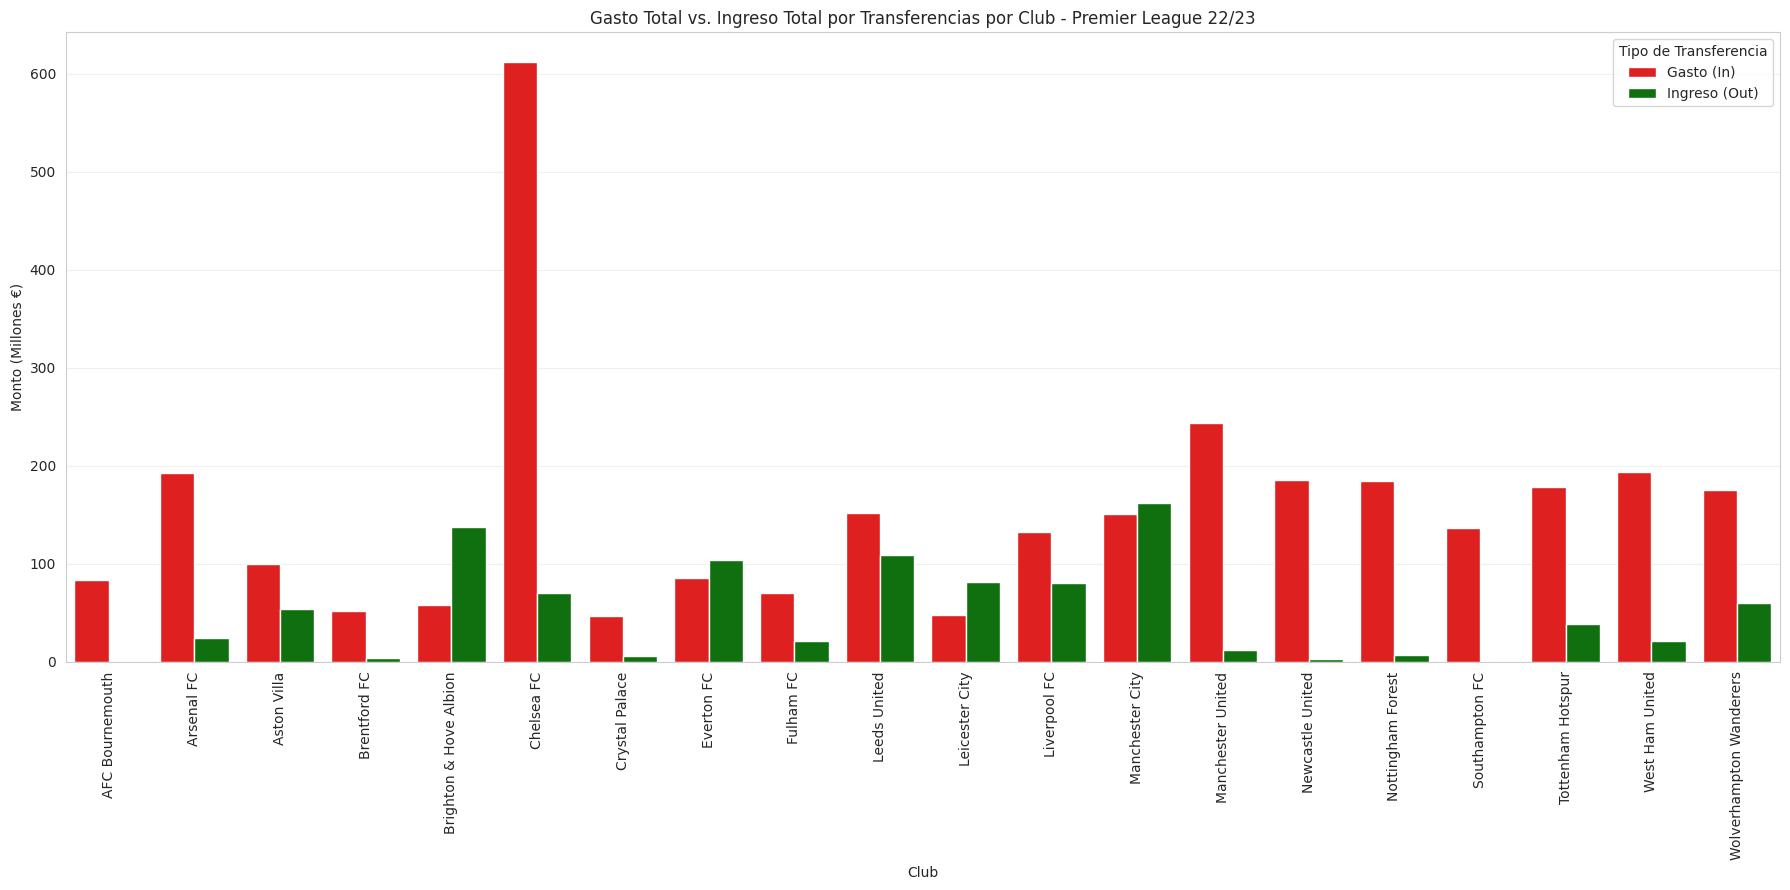

In [11]:

# Desintegra el DataFrame de finanzas para facilitar la representación gráfica con seaborn.
finanzas_melted = finanzas.melt(id_vars='club',
                                value_vars=['gasto_total_in_M', 'ingreso_total_out_M'],
                                var_name='Transfer_Type',
                                value_name='Amount_M_Euro')

# Cambiamos las etiquetas del DataFrame para que aparezcan correctamente en la leyenda automática
finanzas_melted['Transfer_Type'] = finanzas_melted['Transfer_Type'].map({
    'gasto_total_in_M': 'Gasto (In)',
    'ingreso_total_out_M': 'Ingreso (Out)'
})

plt.figure(figsize=(18, 9))

# Definimos los nuevos colores en la paleta usando los nuevos nombres
sns.barplot(
    x='club',
    y='Amount_M_Euro',
    hue='Transfer_Type',
    data=finanzas_melted,
    palette={'Gasto (In)': 'red', 'Ingreso (Out)': 'green'}
)

plt.xlabel('Club')
plt.ylabel('Monto (Millones €)')
plt.title('Gasto Total vs. Ingreso Total por Transferencias por Club - Premier League 22/23')
plt.xticks(rotation=90)

# Dejamos que plt.legend use las etiquetas reales del DataFrame para no romper los colores
plt.legend(title='Tipo de Transferencia')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Este gráfico de barras agrupadas muestra claramente el monto total que cada club gastó en nuevos jugadores y el monto total que recibió por la venta de jugadores en millones de euros

-----------------------------

## 📊 Transferencias en la Premier League (de 2018 a 2023)
### Gráfico de gastos, ingresos y balance por temporada

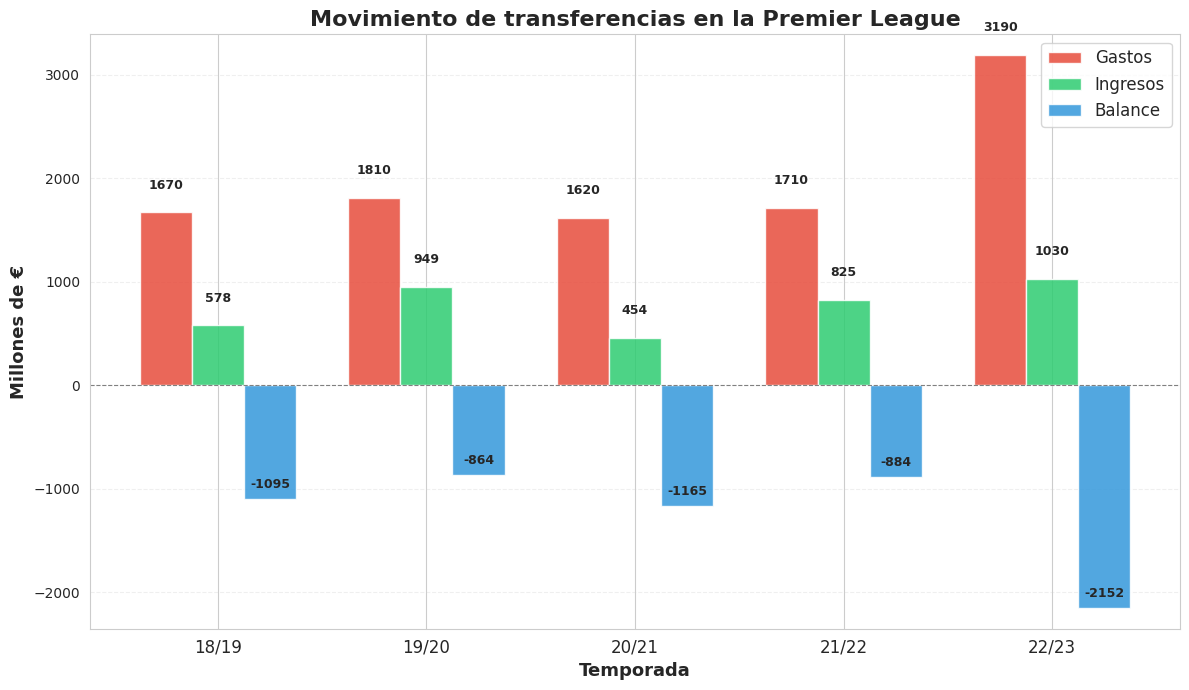

In [12]:
# %% [markdown]


#PUESTAS A MANO LOS DATOS PORQ ERAN POCOS

# Temporadas
temporadas = ['18/19', '19/20', '20/21', '21/22', '22/23']

# Datos en millones de €
gastos  = [1670, 1810, 1620, 1710, 3190]    # mil mill. → millones
ingresos = [577.52, 949.47, 453.96, 825.09, 1030]
balance = [-1095.29, -864.47, -1164.84, -884.16, -2151.51]

# %%
# Configuración del gráfico
x = np.arange(len(temporadas))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 7))

# Barras
bars1 = ax.bar(x - width, gastos, width, label='Gastos', color='#e74c3c', alpha=0.85)
bars2 = ax.bar(x, ingresos, width, label='Ingresos', color='#2ecc71', alpha=0.85)
bars3 = ax.bar(x + width, balance, width, label='Balance', color='#3498db', alpha=0.85)

# Línea de referencia en cero para el balance
ax.axhline(y=0, color='gray', linewidth=0.8, linestyle='--')

# Etiquetas y títulos
ax.set_xlabel('Temporada', fontsize=13, fontweight='bold')
ax.set_ylabel('Millones de €', fontsize=13, fontweight='bold')
ax.set_title('Movimiento de transferencias en la Premier League', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(temporadas, fontsize=12)
ax.legend(fontsize=12)

# Agregar valores sobre las barras
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        va = 'bottom' if height >= 0 else 'top'
        offset = 15 if height >= 0 else -15
        ax.annotate(f'{height:.0f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, offset if height >= 0 else -offset),
                    textcoords="offset points",
                    ha='center', va=va, fontsize=9, fontweight='bold')

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

# Ajustar límites del eje Y para dejar espacio a las etiquetas
y_min = min(balance) - 200
y_max = max(gastos) + 200
ax.set_ylim(y_min, y_max)

# Grid en Y
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# %%
#print("📊 Resumen por temporada:")
#print(f"{'Temp.':<8} {'Gastos (M€)':<14} {'Ingresos (M€)':<16} {'Balance (M€)'}")
##for i, t in enumerate(temporadas):
  #  print(f"{t:<8} {gastos[i]:<14,.0f} {ingresos[i]:<16,.2f} {balance[i]:,.2f}")

##Agregado de tabla con posiciones de temporada 21/22

Se agrega tabla de posiciones de 21/22 y se hace un merge con la

In [13]:
# Cargar posiciones 21/22 y unir con 22/23
url_posiciones_21_22 = 'https://raw.githubusercontent.com/nicotucci/TP-Laboratorio-AnalisisFutbol/375751256a1c519d570caec12bbfde865f0a4a39/Datasets/premier%20posiciones%2021_22%20-%20Sheet1.csv'
posiciones_21_22 = pd.read_csv(url_posiciones_21_22)
posiciones_21_22['club'] = posiciones_21_22['Equipo']
posiciones_21_22 = posiciones_21_22[['club', 'Pts']].rename(columns={'Pts': 'pts_2122'})

# Unir con tabla de posiciones
# Normalizar nombres de clubes (tu tabla posiciones usa 'Arsenal FC' vs 'Arsenal FC'? Está igual)
# Verificar coincidencias
posiciones['club'] = posiciones['Club']  # renombrar
# Unir con el DataFrame 'union' que ya tiene pts_2223 y gasto neto
union = pd.merge(posiciones, finanzas, on='club', how='left').fillna(0)
union = pd.merge(union, posiciones_21_22, on='club', how='left')


## Mostrando como se distribuye el gasto neto en cantidad de equipos

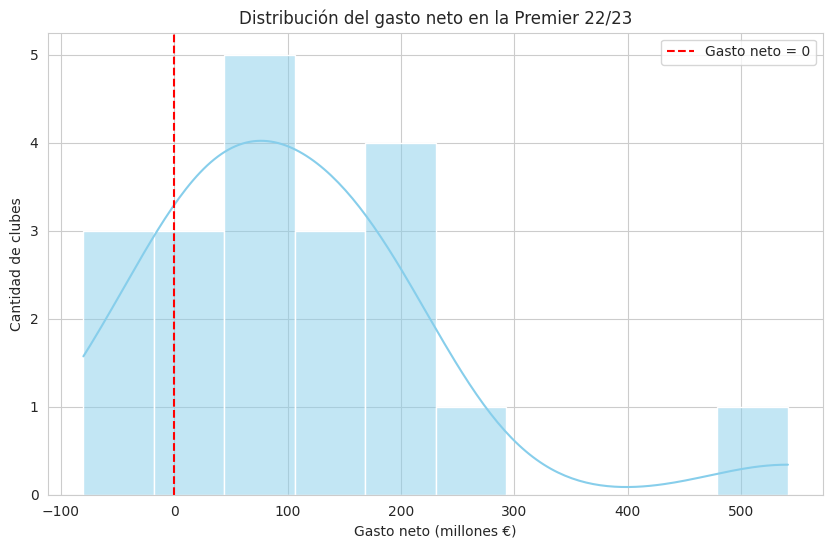

In [14]:
# Gráfico B: histograma de gasto neto
plt.figure(figsize=(10,6))
sns.histplot(union['gasto_neto_M'], bins=10, kde=True, color='skyblue')
plt.xlabel('Gasto neto (millones €)')
plt.ylabel('Cantidad de clubes')
plt.title('Distribución del gasto neto en la Premier 22/23')
plt.axvline(x=0, color='red', linestyle='--', label='Gasto neto = 0')
plt.legend()
plt.savefig('graficoB_histograma_gasto.png')
plt.show()

# Edad promedio de los fichajes por club (histograma)
Se agrupa por club y se saca la media

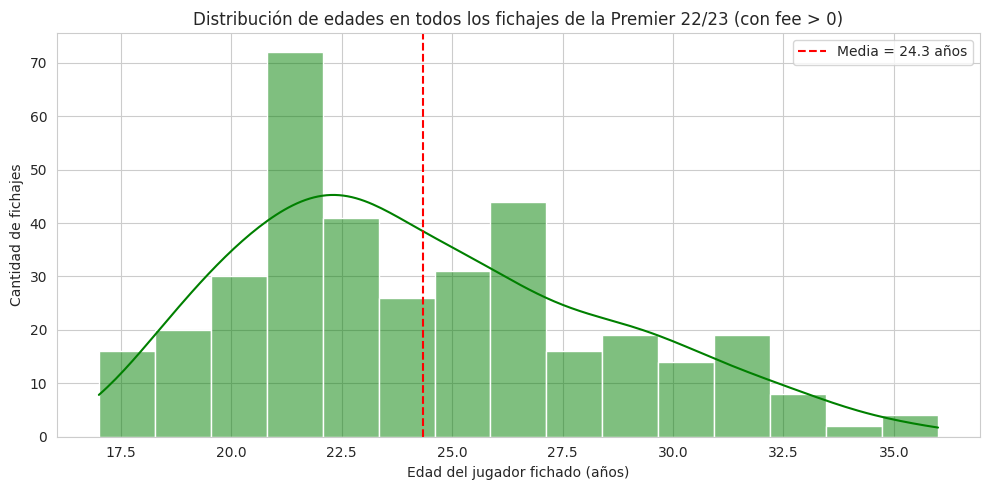

In [15]:
# =============================================
# Gráfico 3: Edad promedio de los fichajes por club (boxplot o histograma)
# Tipo: distribución (a) - usamos boxplot para comparar distribuciones entre clubes
# =============================================
# Calcular edad promedio de los fichajes IN (excluyendo end of loan y sin fee)
transfers_in = transfers[transfers['transfer_movement'] == 'in'].copy()


# Filtrar solo transferencias con fee > 0 (para evitar préstamos sin costo y retornos)
#esto de abajo al final no
#transfers_in = transfers_in[transfers_in['fee_cleaned'] > 0]

# Calcular edad media por club
edad_media = transfers_in.groupby('club_name')['age'].mean().reset_index()
edad_media.columns = ['Club', 'edad_promedio_fichajes']

# Unir con union para tener solo los de Premier
edad_media_premier = pd.merge(union[['Club']], edad_media, on='Club', how='inner')

# Opción: boxplot de la distribución de edades entre clubes (no tiene mucho sentido porque cada club da un valor)
# Mejor: histograma de edades de todos los fichajes (para ver la distribución general)
plt.figure(figsize=(10,5))
sns.histplot(transfers_in['age'], bins=15, kde=True, color='green')
plt.xlabel('Edad del jugador fichado (años)')
plt.ylabel('Cantidad de fichajes')
plt.title('Distribución de edades en todos los fichajes de la Premier 22/23 (con fee > 0)')
plt.axvline(x=transfers_in['age'].mean(), color='red', linestyle='--', label=f'Media = {transfers_in["age"].mean():.1f} años')
plt.legend()
plt.tight_layout()
plt.savefig('grafico_intermedio_3_distribucion_edades.png')
plt.show()

## Grafico de dispersion: base para responder la pregunta formulada

Se realiza grafico Scatter plot relacionando la variable gasto neto y punto obtenidos. se busca medir la correlacion lineal

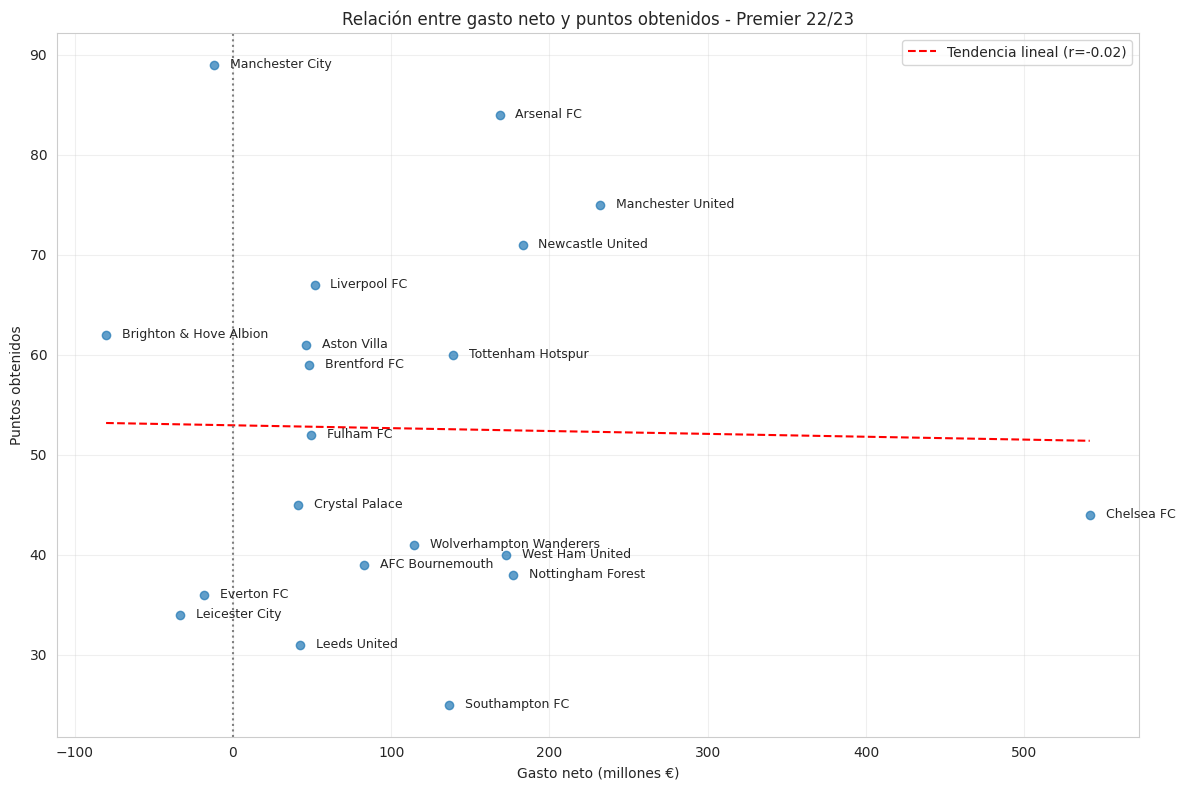

In [16]:
# Celda 7: Gráfico 1 - Dispersión gasto neto vs puntos obtenidos
plt.figure(figsize=(12,8)) # Aumentar el tamaño para el texto

# Merge posiciones and finanzas to create the union DataFrame
union = pd.merge(posiciones, finanzas, left_on='Club', right_on='club', how='inner')

union['posicion'] = union['#']  # asumiendo que la columna se llama '#'
union['puntos']=union['Pts']


# Crear el scatter plot
plt.scatter(union['gasto_neto_M'], union['puntos'], alpha=0.7)

# Ajustar regresión lineal
z = np.polyfit(union['gasto_neto_M'], union['puntos'], 1)
p = np.poly1d(z)

# Corrected correlation for the label to match the Y-axis (puntos)
r_value = np.corrcoef(union['gasto_neto_M'], union['puntos'])[0,1]
plt.plot(sorted(union['gasto_neto_M']), p(sorted(union['gasto_neto_M'])), "r--", label=f"Tendencia lineal (r={r_value:.2f})")

# Añadir etiquetas de texto para cada punto (nombre del club)
for i, row in union.iterrows():
    plt.text(row['gasto_neto_M'] + 10, row['puntos'], row['Club'], fontsize=9, ha='left', va='center')

plt.axvline(x=0, linestyle='dotted', color='grey')
plt.xlabel('Gasto neto (millones €)')
plt.ylabel('Puntos obtenidos')
plt.title('Relación entre gasto neto y puntos obtenidos - Premier 22/23')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('grafico1_dispersion_gasto_vs_posicion_con_nombres.png') # Guardar con un nuevo nombre
plt.show()

#Conclusiones del análisis de correlación y el gráfico

Seccion de pregunta y conclusion [b)¿Porqué vale la pena responderla?](#scrollTo=XSg43JcI7CUB)


**Correlación Débil a Nula:** El coeficiente de correlación de Pearson de -0.02 indica una relación lineal muy débil y prácticamente insignificante entre el gasto neto en transferencias y los puntos obtenidos. Esto significa que el gasto neto por sí solo no es un predictor fuerte de la cantidad de puntos que se obtienen en la Premier League 2022/23.

**Tendencia General Muy Suave:** Aunque la línea de tendencia lineal muestra una ligera inclinación hacia abajo, esta tendencia es extremadamente tenue y no sugiere un patrón claro donde un mayor gasto garantice mayor obtencion de puntos.

***Presencia de Outliers y Casos Particulares:***

**Chelsea:** Destaca por un gasto neto muy alto, pero su posición final fue significativamente más baja de lo que la línea de tendencia podría sugerir, lo que lo convierte en un outlier negativo en términos de eficiencia de gasto.

**Brighton & Hove Albion:** Demuestra una gran eficiencia, logrando una buena posición con un gasto neto bajo o incluso negativo (indicando una venta neta de jugadores superior a las compras).

**Newcastle United**: Muestra una buena combinación de inversión y rendimiento, obteniendo una posición alta con una inversión considerable, pero no exorbitante en comparación con los líderes de gasto.

Los 'Big Six' (o equipos tradicionalmente fuertes): Muchos de ellos tienen gastos netos elevados, pero su rendimiento varía.

**Manchester City** (campeón) y **Arsenal** (subcampeón) son ejemplos de altos gastos con éxito deportivo, pero esto no es universal.

**Otros Factores en Juego:** La ausencia de una correlación fuerte sugiere que otros factores, como la gestión del equipo, la táctica, el desarrollo de jugadores jóvenes, la cohesión del equipo, la suerte con las lesiones y el rendimiento individual, juegan un papel mucho más importante en la determinación de la posición final que el simple volumen de gasto neto en transferencias.

**Encontramos evidencia de que no existe una relación lineal significativa**

En resumen, el gráfico y la correlación numérica sugieren que, si bien la inversión en fichajes puede ser una estrategia, no es el único ni el principal determinante del éxito en la Premier League. Hay clubes que logran mucho con poco y otros que gastan mucho con resultados decepcionantes.



### ✅ Grafico complemento de comparacion con la temporada anterior entre gasto neto y rendimiento. para apoyarse en no solo quedarse con una temporada

Se seleccionan 4 equipos que notamos particularidades los cuales se comparara su gasto neto y punto obtenidos, para la temporada analizada antes (22/23) y con la anterior (21/22) para mostrar el movimiento de una a otra

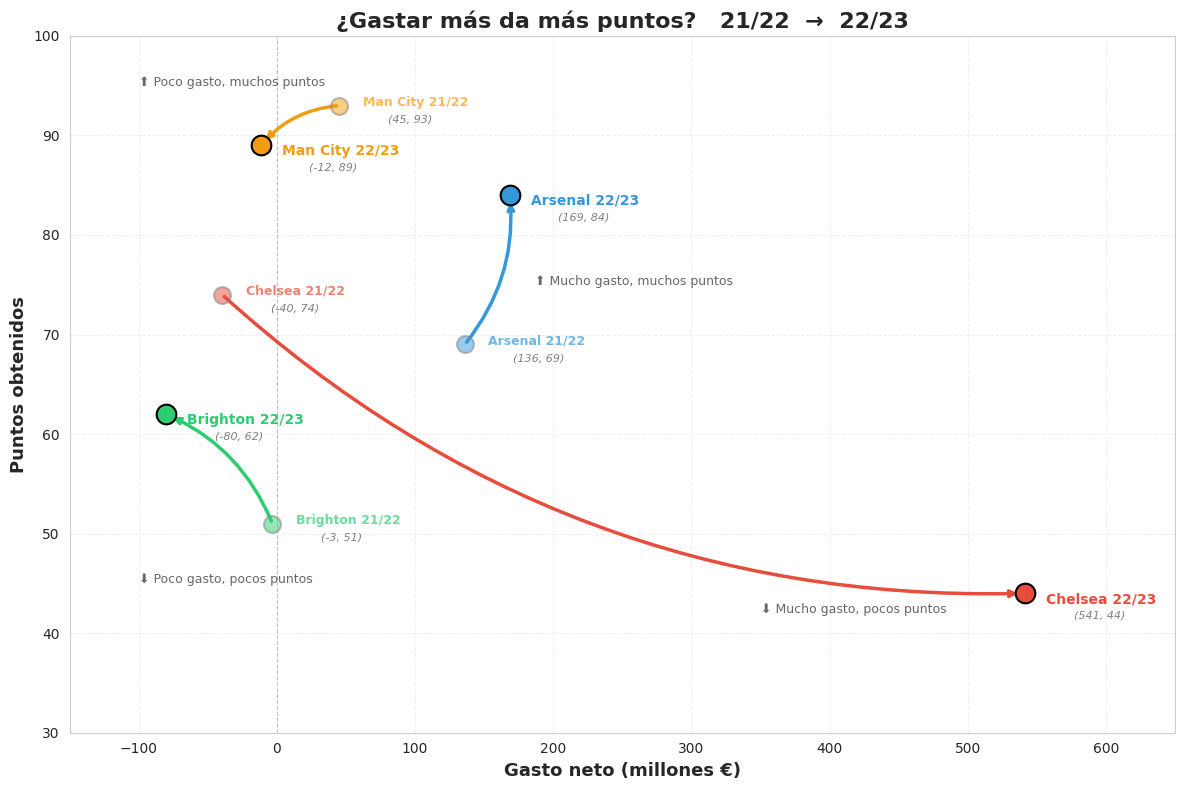

In [17]:
# Datos
equipos = ['Chelsea', 'Brighton', 'Arsenal', 'Man City']

# 21/22
gasto_21 = [-39.59, -3.22, 136, 45.10]
puntos_21 = [74, 51, 69, 93]

# 22/23
gasto_22 = [541.39, -80, 168.56, -11.70]
puntos_22 = [44, 62, 84, 89]

# Colores
colores = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']

fig, ax = plt.subplots(figsize=(12, 8))

for i, eq in enumerate(equipos):
    # Flecha de 21/22 → 22/23
    ax.annotate('', xy=(gasto_22[i], puntos_22[i]),
                xytext=(gasto_21[i], puntos_21[i]),
                arrowprops=dict(arrowstyle='->', color=colores[i],
                                lw=2.5, connectionstyle='arc3,rad=0.2', shrinkB=5))

    # Punto 21/22 (más claro)
    ax.scatter(gasto_21[i], puntos_21[i], c=[colores[i]], s=150, zorder=5,
               edgecolors='gray', linewidth=1.5, alpha=0.5)
    ax.annotate(f'{eq} 21/22', (gasto_21[i], puntos_21[i]),
                xytext=(17, 0), textcoords="offset points",
                fontsize=9, color=colores[i], fontweight='bold', alpha=0.7)

    # Punto 22/23 (más intenso)
    ax.scatter(gasto_22[i], puntos_22[i], c=[colores[i]], s=200, zorder=5,
               edgecolors='black', linewidth=1.5)
    ax.annotate(f'{eq} 22/23', (gasto_22[i], puntos_22[i]),
                xytext=(15, -7), textcoords="offset points",
                fontsize=10, color=colores[i], fontweight='bold')

    # Valor al lado
    ax.annotate(f'({gasto_22[i]:.0f}, {puntos_22[i]})',
                (gasto_22[i], puntos_22[i]),
                xytext=(35, -18), textcoords="offset points",
                fontsize=8, color='gray', fontstyle='italic')
    ax.annotate(f'({gasto_21[i]:.0f}, {puntos_21[i]})',
                (gasto_21[i], puntos_21[i]),
                xytext=(35,-12), textcoords="offset points",
                fontsize=8, color='gray', fontstyle='italic')

ax.axhline(y=0, color='gray', linewidth=0.8, linestyle='--', alpha=0.4)
ax.axvline(x=0, color='gray', linewidth=0.8, linestyle='--', alpha=0.4)

ax.set_xlabel('Gasto neto (millones €)', fontsize=13, fontweight='bold')
ax.set_ylabel('Puntos obtenidos', fontsize=13, fontweight='bold')
ax.set_title('¿Gastar más da más puntos?   21/22  →  22/23',
             fontsize=16, fontweight='bold')

ax.set_xlim(-150, 650)
ax.set_ylim(30, 100)

# Texto en cuadrantes
ax.text(187, 75, '⬆ Mucho gasto, muchos puntos', fontsize=9, color='black', alpha=0.6)
ax.text(350, 42, '⬇ Mucho gasto, pocos puntos', fontsize=9, color='black', alpha=0.6)
ax.text(-100, 95, '⬆ Poco gasto, muchos puntos', fontsize=9, color='black', alpha=0.6)
ax.text(-100, 45, '⬇ Poco gasto, pocos puntos', fontsize=9, color='black', alpha=0.6)

ax.grid(linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

###Conclusion final de esta parte

A partir del análisis de las temporadas 2021/22 y 2022/23 de la Premier League, no encontramos evidencia de una correlación lineal significativa entre el gasto neto en fichajes y los puntos obtenidos (r = -0.02 para la temporada 22/23, y valores igualmente bajos para la 21/22). Esto indica que, en el corto plazo, el saldo de transferencias no es un factor determinante del rendimiento deportivo. El análisis de casos particulares —como el elevado gasto del Chelsea 22/23 con pobres resultados, o la eficiencia del Manchester City con bajo gasto neto— refuerza la idea de que variables como la masa salarial, la continuidad del entrenador, las lesiones y la gestión deportiva tienen un peso mucho mayor. Por lo tanto, rechazamos la hipótesis de una relación lineal directa; el éxito en la Premier League no se compra únicamente con un alto gasto neto en fichajes.

------------------------------------------------------

###🔍**En el primer análisis, centrado únicamente en el gasto neto en fichajes de la temporada 2022/23, obtuvimos un coeficiente de correlación prácticamente nulo (r = -0.02) y un R² cercano a cero. Esto indicaba que el saldo de transferencias, por sí solo, no explicaba en absoluto la cantidad de puntos obtenidos. Sin embargo, diversos estudios y fuentes especializadas señalan que la masa salarial es un factor mucho más determinante del rendimiento deportivo que los fichajes puntuales. Por esta razón, decidimos ampliar nuestro análisis:**

-  **Incorporamos cuatro temporadas completas (2022/23 a 2025/26) para aumentar la muestra.**

- **Reemplazamos la variable “gasto neto en fichajes” por gasto total = fichajes + salarios anuales de cada club.**

- **Mantuvimos como variable dependiente los puntos obtenidos en cada temporada .**

###**El objetivo era evaluar si, al considerar el esfuerzo económico real de cada temporada (incluyendo los salarios, que representan el gasto recurrente más pesado), la relación lineal con los puntos se volvía más clara y fuerte.**


--------------------------------------------------------------------------------

# ❓ ¿Se pueden comprar los puntos?
## Gasto, salarios y rendimiento en la Premier League (4 temporadas: 22/23 → 25/26)


### Resumen
Analizamos la relación entre el **gasto de los clubes** (salarios + fichajes) y su **rendimiento**
(puntos) en la Premier League a lo largo de **cuatro temporadas (2022/23 a 2025/26)**. La base permite
algo poco común: un **panel balanceado de 17 clubes presentes en las cuatro temporadas**, lo que hace
el análisis mucho más robusto. Estudiamos qué pesa más (¿salarios o fichajes?), cómo evolucionó el
"precio del punto" y un fenómeno llamativo del período: en **2023/24 y 2024/25 los tres equipos
ascendidos descendieron**, dejando intacto el núcleo de 17 — la *trampa de los ascendidos*. Se aplican
conceptos de la materia (elasticidad, función de costo, rendimientos decrecientes, margen/rentabilidad).

> **Sobre el uso de IA.** Notebook elaborado con asistencia de un modelo (Claude) para estructura,
> código y redacción; la interpretación es del grupo. Celdas con asistencia directa: `# [IA] Prompt: ...`.

In [18]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, os, warnings
import sympy as sp          # derivadas simbólicas (1ra y 2da) para la optimización
import pulp                 # programación lineal para asignar el presupuesto
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 150)
plt.rcParams.update({"figure.dpi":120,"figure.facecolor":"white","axes.facecolor":"#fbfbfd",
    "axes.grid":True,"grid.color":"#e5e7eb","grid.alpha":0.9,"axes.spines.top":False,
    "axes.spines.right":False,"axes.titlesize":13,"axes.titleweight":"bold","font.size":11})
AZUL="#2563eb"; VIOLETA="#7c3aed"; VERDE="#16a34a"; ROJO="#dc2626"; NARANJA="#f59e0b"; GRIS="#64748b"

def etiquetar_barras_h(ax, valores, fmt="{:.1f}", sufijo=""):
    '''Escribe el valor al final de cada barra horizontal.'''
    for i, v in enumerate(valores):
        ax.text(v, i, "  "+fmt.format(v)+sufijo, va="center", ha="left", fontsize=8.5, color="#111827")

# Fuente de datos: repositorio de GitHub del grupo (raw). El notebook la baja sola.
URL_GITHUB = "https://raw.githubusercontent.com/nicotucci/TP-Laboratorio-AnalisisFutbol/main/Datasets/base_scouting_completa.xlsx"
ARCHIVO_LOCAL = "base_scouting_actualizada_2.xlsx"   # respaldo local (misma base, por si falla GitHub)
SEAS = {"22":"22/23", "23":"23/24", "24":"24/25", "25":"25/26"}   # las 4 temporadas del panel
os.makedirs("figuras", exist_ok=True)
print("Fuente principal:", URL_GITHUB)

Fuente principal: https://raw.githubusercontent.com/nicotucci/TP-Laboratorio-AnalisisFutbol/main/Datasets/base_scouting_completa.xlsx


## 1. Carga y exploración inicial  *(consigna 3.1)*
### 1.a) Carga y vista de las primeras/últimas filas

In [19]:
# [IA] Prompt: "Cargá la base desde la URL raw de GitHub; si el archivo no tiene las 4 temporadas
#               (falta Detalle_Traspasos_25) o falla la descarga, usá el archivo local de respaldo."
def cargar_base():
    # 1) intento desde el repositorio de GitHub
    try:
        xls = pd.ExcelFile(URL_GITHUB)
        if "Detalle_Traspasos_25" in xls.sheet_names:      # validación: ¿es la base de 4 temporadas?
            print("✓ Base cargada desde GitHub.")
            return xls
        print("⚠ El archivo del repo es una versión vieja (sin temporadas 23/24/25). Uso el respaldo local.")
    except Exception as e:
        print("⚠ No se pudo leer desde GitHub:", str(e)[:80], "→ uso el respaldo local.")
    # 2) respaldo: archivo local en la sesión
    return pd.ExcelFile(ARCHIVO_LOCAL)

xls = cargar_base()
print("Hojas:", xls.sheet_names)
hojas = {h: pd.read_excel(xls, sheet_name=h) for h in xls.sheet_names}
maestro = hojas["Maestro_Clubes"]
print("\n.head():"); display(maestro.head())
print(".tail():"); display(maestro.tail())

✓ Base cargada desde GitHub.
Hojas: ['Maestro_Clubes', 'Detalle_Traspasos_21', 'Detalle_Traspasos_22', 'LIGAS_INFO', 'ESTADISTICAS_21', 'ESTADISTICAS_22', 'Detalle_Traspasos_23', 'Detalle_Traspasos_24', 'Detalle_Traspasos_25']

.head():


,CLUBES,CONTRATOS_21,SALARIOS_AÑO_21,CONTRATOS_22,SALARIOS_AÑO_22,PUNTOS_21,PUNTOS_22,INGRESOS_FICHAJES_21_M$,INGRESOS_FICHAJES_22_M$,GASTOS_FICHAJES_21_M$,GASTOS_FICHAJES_22_M$,BALANCE_21_M$,BALANCE_22_M$,CONTRATOS_23,SALARIOS_AÑO_23,CONTRATOS_24,SALARIOS_AÑO_24,CONTRATOS_25,SALARIOS_AÑO_25,PUNTOS_23,PUNTOS_24,PUNTOS_25,INGRESOS_FICHAJES_23_M$,INGRESOS_FICHAJES_24_M$,INGRESOS_FICHAJES_25_M$,GASTOS_FICHAJES_23_M$,GASTOS_FICHAJES_24_M$,GASTOS_FICHAJES_25_M$,BALANCE_23_M$,BALANCE_24_M$,BALANCE_25_M$
0,ARSENAL,70.0,"$138,984,848",69,"$129,210,591",69.0,84,34.54,26.18,184.14,205.04,-149.60,-178.86,30.0,"$200,500,000",31.0,"$225,000,000",32.0,"$290,000,000",89.0,74.0,85.0,33.02,57.15,0.0,293.37,127.00,391.96,-260.35,-69.85,-391.96
1,ASTON VILLA,66.0,"$86,876,165",81,"$127,888,743",45.0,61,139.70,59.40,142.78,124.30,-3.08,-64.90,29.0,"$130,000,000",32.0,"$170,000,000",33.0,"$195,000,000",68.0,66.0,65.0,0.00,0.00,0.0,124.46,109.22,66.00,-124.46,-109.22,-66.00
2,BRENTFORD,90.0,"$25,677,627",75,"$40,845,084",46.0,59,1.10,3.96,42.02,54.18,-40.92,-50.22,28.0,"$56,000,000",27.0,"$62,000,000",27.0,"$68,000,000",39.0,56.0,53.0,0.00,0.00,198.0,57.40,30.48,59.40,-57.40,-30.48,138.60
3,BRIGHTON,76.0,"$56,471,332",73,"$48,776,174",51.0,62,86.68,152.24,83.14,61.27,3.54,90.97,29.0,"$90,000,000",30.0,"$105,000,000",30.0,"$115,000,000",48.0,61.0,53.0,171.45,22.86,0.0,48.26,66.04,0.00,123.19,-43.18,0.00
4,BURNLEY,72.0,"$48,025,544",0,0,35.0,0,44.55,0.00,54.34,0.00,-9.79,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


.tail():


,CLUBES,CONTRATOS_21,SALARIOS_AÑO_21,CONTRATOS_22,SALARIOS_AÑO_22,PUNTOS_21,PUNTOS_22,INGRESOS_FICHAJES_21_M$,INGRESOS_FICHAJES_22_M$,GASTOS_FICHAJES_21_M$,GASTOS_FICHAJES_22_M$,BALANCE_21_M$,BALANCE_22_M$,CONTRATOS_23,SALARIOS_AÑO_23,CONTRATOS_24,SALARIOS_AÑO_24,CONTRATOS_25,SALARIOS_AÑO_25,PUNTOS_23,PUNTOS_24,PUNTOS_25,INGRESOS_FICHAJES_23_M$,INGRESOS_FICHAJES_24_M$,INGRESOS_FICHAJES_25_M$,GASTOS_FICHAJES_23_M$,GASTOS_FICHAJES_24_M$,GASTOS_FICHAJES_25_M$,BALANCE_23_M$,BALANCE_24_M$,BALANCE_25_M$
18,WEST HAM,77.0,"$90,602,030",69,"$104,756,412",56.0,40,4.66,23.71,81.95,216.26,-77.30,-192.56,29.0,"$115,000,000",28.0,"$120,000,000",27.0,"$125,000,000",52.0,43.0,39.0,196.85,0.00,0.00,152.40,152.40,26.4,44.45,-152.40,-26.40
19,WOLVES,76.0,"$69,595,717",88,"$66,323,698",51.0,41,34.98,71.36,41.36,197.46,-6.38,-126.10,27.0,"$78,000,000",26.0,"$82,000,000",25.0,"$88,000,000",46.0,40.0,20.0,139.70,119.38,132.44,46.99,80.01,0.0,92.71,39.37,132.44
20,BOURNEMOUTH,NaN,NaN,28,"$64,000,000",NaN,39,NaN,0.00,NaN,44.34,NaN,-44.34,27.0,"$72,000,000",27.0,"$82,000,000",28.0,"$95,000,000",48.0,56.0,57.0,76.20,0.00,0.00,77.47,53.59,26.4,-1.27,-53.59,-26.40
21,FULHAM,NaN,NaN,27,"$83,000,000",NaN,52,NaN,8.98,NaN,108.95,NaN,-99.97,27.0,"$95,000,000",28.0,"$102,000,000",27.0,"$112,000,000",47.0,54.0,52.0,63.50,0.00,0.00,75.18,84.07,0.0,-11.68,-84.07,0.00
22,NOTTINGHAM FOREST,NaN,NaN,33,"$115,000,000",NaN,38,NaN,6.41,NaN,143.73,NaN,-137.32,30.0,"$98,000,000",31.0,"$115,000,000",30.0,"$145,000,000",32.0,65.0,44.0,0.00,0.00,0.00,98.55,41.14,72.6,-98.55,-41.14,-72.60


### 1.b) Estructura, dimensiones, tipos y cobertura

In [20]:
print("Dimensiones por hoja:")
for h, df in hojas.items(): print(f"  {h:<22} {df.shape}")
pts_cols = [c for c in maestro.columns if c.startswith("PUNTOS_")]
print("\nTemporadas con datos de puntos:", pts_cols, "(sufijos 21..25 = 2021/22..2025/26)")
print("Clubes por temporada (con puntos>0):")
for c in pts_cols:
    print(f"  {c}: {(pd.to_numeric(maestro[c],errors='coerce').fillna(0)>0).sum()} clubes")
print("\nTipos de dato (.dtypes), primeras columnas:"); print(maestro.dtypes.head(8))

Dimensiones por hoja:
  Maestro_Clubes         (23, 31)
  Detalle_Traspasos_21   (280, 7)
  Detalle_Traspasos_22   (387, 7)
  LIGAS_INFO             (5, 5)
  ESTADISTICAS_21        (537, 282)
  ESTADISTICAS_22        (550, 282)
  Detalle_Traspasos_23   (118, 7)
  Detalle_Traspasos_24   (85, 7)
  Detalle_Traspasos_25   (70, 7)

Temporadas con datos de puntos: ['PUNTOS_21', 'PUNTOS_22', 'PUNTOS_23', 'PUNTOS_24', 'PUNTOS_25'] (sufijos 21..25 = 2021/22..2025/26)
Clubes por temporada (con puntos>0):
  PUNTOS_21: 20 clubes
  PUNTOS_22: 20 clubes
  PUNTOS_23: 17 clubes
  PUNTOS_24: 17 clubes
  PUNTOS_25: 17 clubes

Tipos de dato (.dtypes), primeras columnas:
CLUBES                      object
CONTRATOS_21               float64
SALARIOS_AÑO_21             object
CONTRATOS_22                 int64
SALARIOS_AÑO_22             object
PUNTOS_21                  float64
PUNTOS_22                    int64
INGRESOS_FICHAJES_21_M$    float64
dtype: object


### 1.c) Calidad: nulos, duplicados, descriptivos y el núcleo de 17 clubes

In [21]:
print("Nulos y duplicados por hoja:")
for h, df in hojas.items():
    print(f"  {h:<22} nulos={int(df.isnull().sum().sum()):>5}  duplicados={int(df.duplicated().sum())}")

# Identificar los clubes presentes en las 4 temporadas 22..25
def en_liga(yr): return pd.to_numeric(maestro[f"PUNTOS_{yr}"], errors="coerce").fillna(0) > 0
mask_core = en_liga("22") & en_liga("23") & en_liga("24") & en_liga("25")
CORE = maestro.loc[mask_core, "CLUBES"].tolist()
print(f"\n>> Núcleo estable: {len(CORE)} clubes presentes en las 4 temporadas 22/23–25/26:")
print("  ", ", ".join(c.title() for c in CORE))

print("\n>> Problemas de calidad detectados:")
print("   1) SALARIOS como texto:", repr(maestro['SALARIOS_AÑO_22'].iloc[0]))
print("   2) Detalle_Traspasos_22 sin encabezado y con columnas en otro orden (Posición/Tipo intercambiados).")
print("   3) Temporadas 21/22 y 22/23 tienen 20 clubes; 23/24–25/26 tienen 17 (los ascendidos descendieron).")
display(maestro[["PUNTOS_22","PUNTOS_23","PUNTOS_24","PUNTOS_25",
                 "GASTOS_FICHAJES_22_M$","GASTOS_FICHAJES_25_M$"]].describe().round(1))

Nulos y duplicados por hoja:
  Maestro_Clubes         nulos=  126  duplicados=0
  Detalle_Traspasos_21   nulos=    0  duplicados=0
  Detalle_Traspasos_22   nulos=    0  duplicados=1
  LIGAS_INFO             nulos=    0  duplicados=0
  ESTADISTICAS_21        nulos=  537  duplicados=0
  ESTADISTICAS_22        nulos=  550  duplicados=0
  Detalle_Traspasos_23   nulos=    0  duplicados=0
  Detalle_Traspasos_24   nulos=    0  duplicados=0
  Detalle_Traspasos_25   nulos=    0  duplicados=0

>> Núcleo estable: 17 clubes presentes en las 4 temporadas 22/23–25/26:
   Arsenal, Aston Villa, Brentford, Brighton, Chelsea, Crystal Palace, Everton, Liverpool, Manchester City, Manchester United, Newcastle, Tottenham, West Ham, Wolves, Bournemouth, Fulham, Nottingham Forest

>> Problemas de calidad detectados:
   1) SALARIOS como texto: '$129,210,591'
   2) Detalle_Traspasos_22 sin encabezado y con columnas en otro orden (Posición/Tipo intercambiados).
   3) Temporadas 21/22 y 22/23 tienen 20 clubes; 23

,PUNTOS_22,PUNTOS_23,PUNTOS_24,PUNTOS_25,GASTOS_FICHAJES_22_M$,GASTOS_FICHAJES_25_M$
count,23.0,17.0,17.0,17.0,23.0,17.0
mean,45.8,57.6,58.0,53.7,147.7,89.4
std,24.8,17.3,13.1,15.4,142.5,104.2
min,0.0,32.0,38.0,20.0,0.0,0.0
25%,35.0,47.0,48.0,45.0,54.0,13.2
50%,44.0,52.0,56.0,52.0,143.7,59.4
75%,61.5,66.0,66.0,60.0,198.7,143.7
max,89.0,91.0,84.0,85.0,693.3,392.0


**Hallazgos de calidad.** Sin nulos ni duplicados. Tres puntos a resolver: (1) **salarios como texto**
(`$...`) → pasar a número y a millones; (2) **`Detalle_Traspasos_22`** sin encabezado y con columnas
reordenadas → reasignar nombres en el orden real; (3) la liga tiene **20 clubes en 21/22 y 22/23 pero
17 en 23/24–25/26**: esto no es un error sino *el dato más interesante* — en 23/24 y 24/25 los tres
ascendidos descendieron, manteniendo el mismo núcleo de 17. Trabajamos con esos **17 clubes en las 4
temporadas 22/23–25/26** (panel balanceado de 68 observaciones club-temporada).

## 2. Pregunta de investigación  *(consigna 3.2)*

**a) ¿Cuál es la pregunta?** ¿Cuánto explica el gasto (salarios + fichajes) los puntos de un club de la
Premier? ¿Pesan más los **salarios** o los **fichajes**? ¿Y por qué a los recién ascendidos les cuesta
tanto sobrevivir?

**b) ¿Por qué vale la pena?** Es la pregunta económica central del fútbol: si la plata no alcanza, la
*eficiencia* y la *estructura del gasto* mandan. Con 4 temporadas podemos ver tendencias y la brecha
financiera que condena a los ascendidos.

**c) ¿Qué respuesta encontraron?** El gasto ayuda pero explica poco (panel R² ≈ 0,22); los **salarios
predicen el rendimiento mejor que los fichajes**; el "precio del punto" sube por la inflación salarial;
y los ascendidos caen en una **trampa financiera**. Desarrollo y conclusión objetiva en la **sección 9**.

## 3. Transformaciones y resumen estadístico  *(consigna 3.3)*
### 3.a) Transformaciones justificadas

In [22]:
# [IA] Prompt: "Limpiá salarios, arreglá traspasos 22, y armá un panel tidy de 17 clubes x 4 temporadas
#               (22..25) con gasto total y puntos, más promedios por club."
def parsear_dinero(serie):
    '''Texto monetario ('$138,984,848') -> float (quita $ y comas). NaN si no se puede.'''
    return pd.to_numeric(serie.astype(str).str.replace(r"[\$,]", "", regex=True), errors="coerce")

# --- T1+T2: panel tidy (una fila por club-temporada) con salarios en M$ y gasto total ---
filas = []
for _, r in maestro[maestro["CLUBES"].isin(CORE)].iterrows():
    for yr, lbl in SEAS.items():
        sal = parsear_dinero(pd.Series([r[f"SALARIOS_AÑO_{yr}"]])).iloc[0] / 1e6
        fic = pd.to_numeric(pd.Series([r[f"GASTOS_FICHAJES_{yr}_M$"]]), errors="coerce").iloc[0]
        filas.append({"Club": r["CLUBES"], "Temporada": lbl, "Salarios_M": sal,
                      "Fichajes_M": fic, "Gasto_Total_M": sal + fic,
                      "Puntos": pd.to_numeric(pd.Series([r[f"PUNTOS_{yr}"]]), errors="coerce").iloc[0]})
panel = pd.DataFrame(filas)
panel["Costo_por_punto"] = panel["Gasto_Total_M"] / panel["Puntos"]
print("Panel balanceado:", panel.shape, "(17 clubes x 4 temporadas = 68)")

# --- T3: agregado por club (promedio de las 4 temporadas, suaviza outliers) ---
clubes = (panel.groupby("Club")
          .agg(Gasto=("Gasto_Total_M","mean"), Salarios=("Salarios_M","mean"),
               Fichajes=("Fichajes_M","mean"), Puntos=("Puntos","mean")).reset_index())
clubes["Costo_por_punto"] = clubes["Gasto"] / clubes["Puntos"]
clubes["Puntos_por_M"]    = clubes["Puntos"] / clubes["Gasto"]

# --- T4: traspasos de las 5 temporadas (arreglando la hoja 22) ---
cols_std = ["Club_Involucrado","Jugador","Tipo_Movimiento","Subtipo_Movimiento","Posición","Club_Origen_Destino","Coste_M$"]
frames = []
for sh, lbl in [("Detalle_Traspasos_21","21/22"),("Detalle_Traspasos_23","23/24"),
                ("Detalle_Traspasos_24","24/25"),("Detalle_Traspasos_25","25/26")]:
    t = pd.read_excel(xls, sh); t["Temporada"] = lbl; frames.append(t)
t22 = pd.read_excel(xls, "Detalle_Traspasos_22", header=None)
t22.columns = ["Club_Involucrado","Jugador","Posición","Tipo_Movimiento","Subtipo_Movimiento","Club_Origen_Destino","Coste_M$"]
t22 = t22[cols_std]; t22["Temporada"] = "22/23"; frames.append(t22)
traspasos = pd.concat(frames, ignore_index=True)
traspasos["Coste_M$"] = pd.to_numeric(traspasos["Coste_M$"], errors="coerce")
print("Traspasos unificados (5 temporadas):", traspasos.shape)

display(clubes.sort_values("Costo_por_punto").round(1).reset_index(drop=True))

Panel balanceado: (68, 7) (17 clubes x 4 temporadas = 68)
Traspasos unificados (5 temporadas): (941, 8)


,Club,Gasto,Salarios,Fichajes,Puntos,Costo_por_punto,Puntos_por_M
0,BRENTFORD,107.1,56.7,50.4,51.8,2.1,0.5
1,BRIGHTON,133.6,89.7,43.9,56.0,2.4,0.4
2,BOURNEMOUTH,128.7,78.2,50.4,50.0,2.6,0.4
3,CRYSTAL PALACE,135.3,97.0,38.3,48.0,2.8,0.4
4,FULHAM,165.0,98.0,67.0,51.2,3.2,0.3
5,EVERTON,155.8,115.2,40.6,43.2,3.6,0.3
6,ASTON VILLA,261.7,155.7,106.0,65.0,4.0,0.2
7,WOLVES,159.7,78.6,81.1,36.8,4.3,0.2
8,NOTTINGHAM FOREST,207.3,118.2,89.0,44.8,4.6,0.2
9,NEWCASTLE,303.8,162.6,141.3,61.5,4.9,0.2


> **Por qué el panel y los promedios.** Cada club aparece en las 4 temporadas: promediar sus valores da
> una foto estable de cuánto gasta y rinde *típicamente*, y las 68 observaciones hacen los análisis
> mucho más confiables que con una sola temporada.

### 3.b) Resúmenes con `groupby`
**Resumen 1 — costo de las compras por posición** (5 temporadas).

In [23]:
compras = traspasos[(traspasos["Tipo_Movimiento"]=="Alta") & (traspasos["Coste_M$"]>0)]
display(compras.groupby("Posición")["Coste_M$"].agg(cantidad="count", promedio="mean", total="sum")
        .sort_values("promedio", ascending=False).round(1).head(8))

,cantidad,promedio,total
Posición,,,
Delantero centro,38,41.5,1578.0
Extremo izquierdo,24,36.8,884.2
Mediocentro ofensivo,27,36.7,990.1
Pivote,21,33.5,703.6
Extremo derecho,31,31.8,986.3
Defensa central,54,30.5,1648.4
Mediocentro,45,29.0,1304.0
Lateral derecho,15,24.4,365.6


**Resumen 2 — la evolución temporal (el "precio del punto" sube).**

In [24]:
resumen_temp = (panel.groupby("Temporada")
                .agg(salarios_total_M=("Salarios_M","sum"), gasto_total_M=("Gasto_Total_M","sum"),
                     puntos_promedio=("Puntos","mean")).round(1))
resumen_temp["costo_por_punto_prom"] = (resumen_temp["gasto_total_M"]/17/resumen_temp["puntos_promedio"]).round(2)
display(resumen_temp)

,salarios_total_M,gasto_total_M,puntos_promedio,costo_por_punto_prom
Temporada,,,,
22/23,2202.2,5194.5,56.6,5.40
23/24,2514.5,5083.5,57.6,5.19
24/25,2726.0,4028.8,58.0,4.09
25/26,3151.0,4670.1,53.7,5.12


**Interpretación de los `groupby`.** Los **delanteros centro** son la posición más cara y los
**porteros** la más barata: el mercado paga el gol. Y sobre el tiempo, la **masa salarial de los 17
creció con fuerza (+43% en 4 años, de ~2.200 a ~3.150 M$)** mientras los **puntos promedio quedaron
planos (~54–58)**: el *precio del punto sube*. Lo anticipamos acá y lo formalizamos en la sección 5.

## 4. Análisis gráfico  *(consigna 3.4)*
Cinco gráficos de tipos distintos (serie temporal, histograma, barras, dispersión y mapa de
cuadrantes), con título, subtítulo de lectura, ejes con unidades e interpretación. Se exportan a `figuras/`.

### 4.a) Serie temporal — la inflación que no compra puntos  *(tipo líneas)*

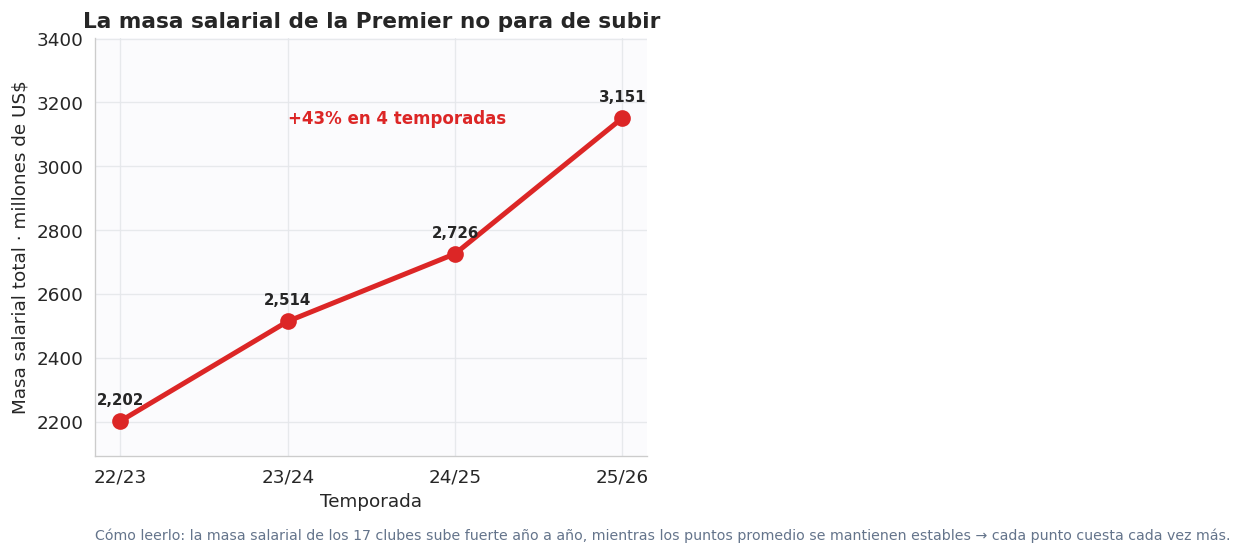

Puntos promedio por temporada (se mantienen estables): [56.6, 57.6, 58.0, 53.7]


In [25]:
temps = list(SEAS.values())
sal = resumen_temp["salarios_total_M"].values
crecimiento = (sal[-1]/sal[0]-1)*100

fig, ax = plt.subplots(figsize=(8.5,4.8))
ax.plot(temps, sal, "o-", color=ROJO, lw=3, markersize=9, label="Masa salarial total (17 clubes)")
for t, v in zip(temps, sal):                       # etiqueta de valor en cada punto
    ax.annotate(f"{v:,.0f}", (t, v), textcoords="offset points", xytext=(0,10), ha="center", fontsize=9, weight="bold")
#flecha de crecimiento total
ax.annotate(f"+{crecimiento:.0f}% en 4 temporadas", xy=(temps[-1], sal[-1]), xytext=(temps[1], sal[-1]),
            fontsize=10, color=ROJO, weight="bold", va="center")
ax.set_title("La masa salarial de la Premier no para de subir")
ax.set_xlabel("Temporada"); ax.set_ylabel("Masa salarial total · millones de US$")
ax.set_ylim(sal.min()*0.95, sal.max()*1.08)
ax.text(0,-0.2,"Cómo leerlo: la masa salarial de los 17 clubes sube fuerte año a año, "
        "mientras los puntos promedio se mantienen estables → cada punto cuesta cada vez más.",
        transform=ax.transAxes, fontsize=8.5, color=GRIS)
plt.tight_layout(); plt.savefig("figuras/g1_tendencia.png", dpi=150, bbox_inches="tight"); plt.show()
print("Puntos promedio por temporada (se mantienen estables):", resumen_temp["puntos_promedio"].round(1).tolist())

###Interpretación

En cuatro temporadas la masa salarial de los 17 clubes creció +43%. Mientras
tanto, los puntos promedio por club casi no se mueven (rondan los ~54–58 en todas las temporadas):
por definición la liga reparte siempre la misma cantidad total de puntos, así que el gasto extra es un
juego de suma cero entre clubes. La conclusión es directa: se infla el costo, no el resultado —
cada punto sale cada vez más caro.

### 4.b) Distribución — ¿cuánto cuestan los fichajes?  *(tipo histograma)*

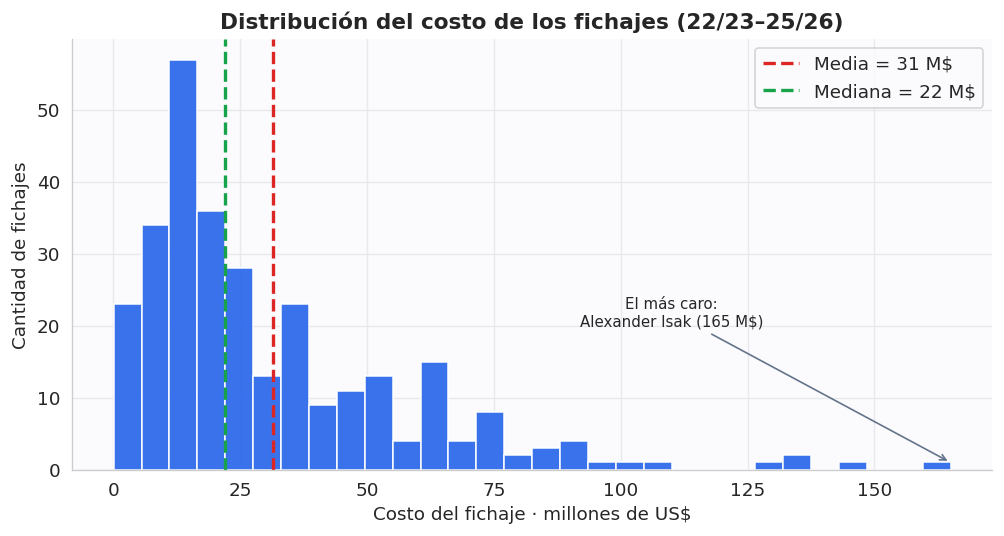

n=295 | media=31.4 | mediana=22.0 | máx=165 M$


In [26]:
fees = compras["Coste_M$"]
fig, ax = plt.subplots(figsize=(8.5,4.6))
ax.hist(fees, bins=30, color=AZUL, edgecolor="white", alpha=0.9)
ax.axvline(fees.mean(),   color=ROJO,  ls="--", lw=2, label=f"Media = {fees.mean():.0f} M$")
ax.axvline(fees.median(), color=VERDE, ls="--", lw=2, label=f"Mediana = {fees.median():.0f} M$")
top = compras.loc[compras["Coste_M$"].idxmax()]
ax.annotate(f"El más caro:\n{top['Jugador']} ({top['Coste_M$']:.0f} M$)", xy=(top["Coste_M$"],1),
            xytext=(top["Coste_M$"]-55, 20), fontsize=9, ha="center",
            arrowprops=dict(arrowstyle="->", color=GRIS))
ax.set_title("Distribución del costo de los fichajes (22/23–25/26)")
ax.set_xlabel("Costo del fichaje · millones de US$"); ax.set_ylabel("Cantidad de fichajes"); ax.legend()
plt.tight_layout(); plt.savefig("figuras/g2_distribucion_fichajes.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"n={len(fees)} | media={fees.mean():.1f} | mediana={fees.median():.1f} | máx={fees.max():.0f} M$")

**Interpretación.** Distribución **muy sesgada a la derecha**: muchos fichajes baratos y pocos
megafichajes (hasta ~165 M$) que estiran la cola. La media supera a la mediana: el gasto de un club lo
suele marcar un par de operaciones estrella más que una política pareja.

### 4.c) Comparación entre clubes — costo por punto  *(tipo barras, promedio 4 temporadas)*

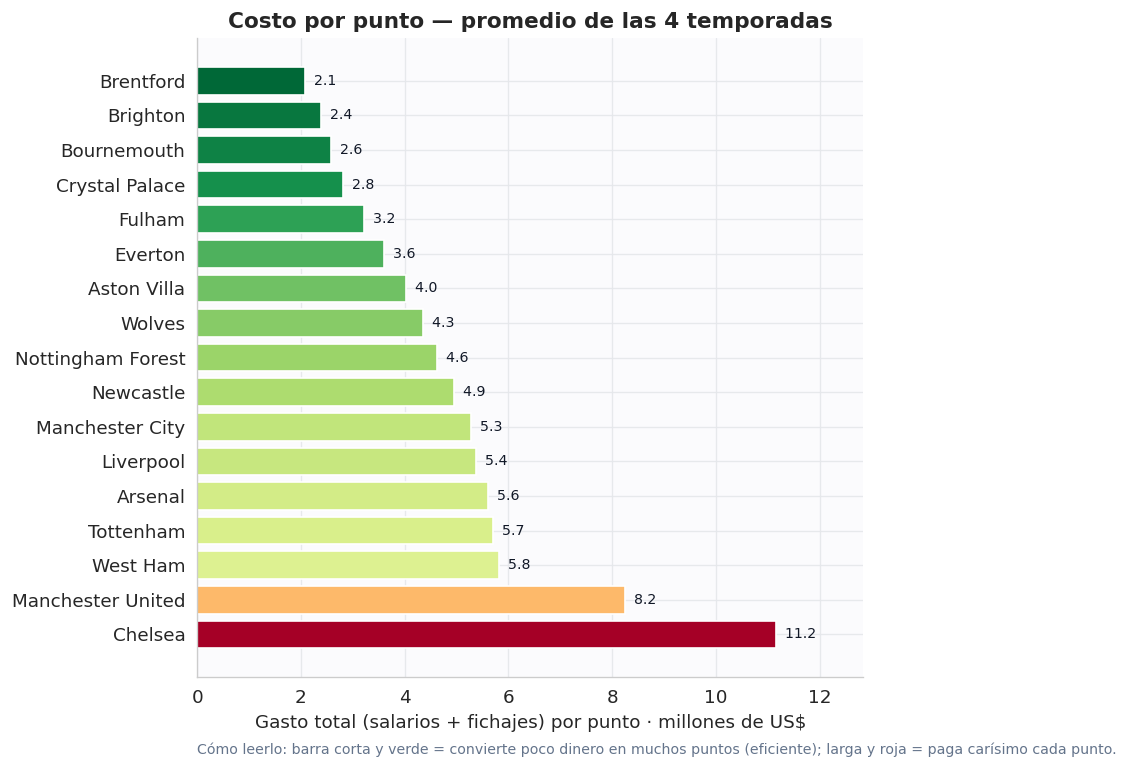

In [27]:
orden = clubes.sort_values("Costo_por_punto")
norm = (orden["Costo_por_punto"]-orden["Costo_por_punto"].min())/(orden["Costo_por_punto"].max()-orden["Costo_por_punto"].min())
fig, ax = plt.subplots(figsize=(8.5,6.5))
ax.barh(orden["Club"].str.title(), orden["Costo_por_punto"], color=plt.cm.RdYlGn_r(norm), edgecolor="white")
etiquetar_barras_h(ax, orden["Costo_por_punto"].values, fmt="{:.1f}")
ax.set_title("Costo por punto — promedio de las 4 temporadas")
ax.set_xlabel("Gasto total (salarios + fichajes) por punto · millones de US$")
ax.set_xlim(0, orden["Costo_por_punto"].max()*1.15); ax.invert_yaxis()
ax.text(0,-0.12,"Cómo leerlo: barra corta y verde = convierte poco dinero en muchos puntos (eficiente); "
        "larga y roja = paga carísimo cada punto.", transform=ax.transAxes, fontsize=8.5, color=GRIS)
plt.tight_layout(); plt.savefig("figuras/g3_costo_por_punto.png", dpi=150, bbox_inches="tight"); plt.show()

**Interpretación.** **Brentford** (~2,1 M$/punto), **Brighton** (~2,4) y **Bournemouth** (~2,6) son las
máquinas de puntos baratos; **Chelsea** (~11,2) y **Manchester United** (~8,2) los más derrochadores. El
dinero **no garantiza** rendimiento: la gestión explica gran parte de la diferencia.

### 4.d) Relación gasto–puntos sobre las 68 observaciones  *(tipo dispersión)*

> **¿Qué son `r` y `R²`?**
> - **`r` (coeficiente de correlación de Pearson)** mide cuán **alineados** están dos variables en una recta.
>   Va de **−1 a +1**: cerca de +1, cuando una sube la otra sube; cerca de 0, no hay relación lineal;
>   cerca de −1, cuando una sube la otra baja. Acá `r ≈ 0,46`: relación positiva pero **floja**.
> - **`R²` (coeficiente de determinación)** es `r` al cuadrado y se lee como **el porcentaje de la
>   variación de los puntos que el gasto logra explicar**. `R² ≈ 0,21` significa que el gasto explica
>   apenas **~21%** de las diferencias de puntos entre clubes; el **~79% restante** depende de otras
>   cosas (gestión, cuerpo técnico, lesiones, suerte). Cuanto más cerca de 1, mejor "explica" el modelo.

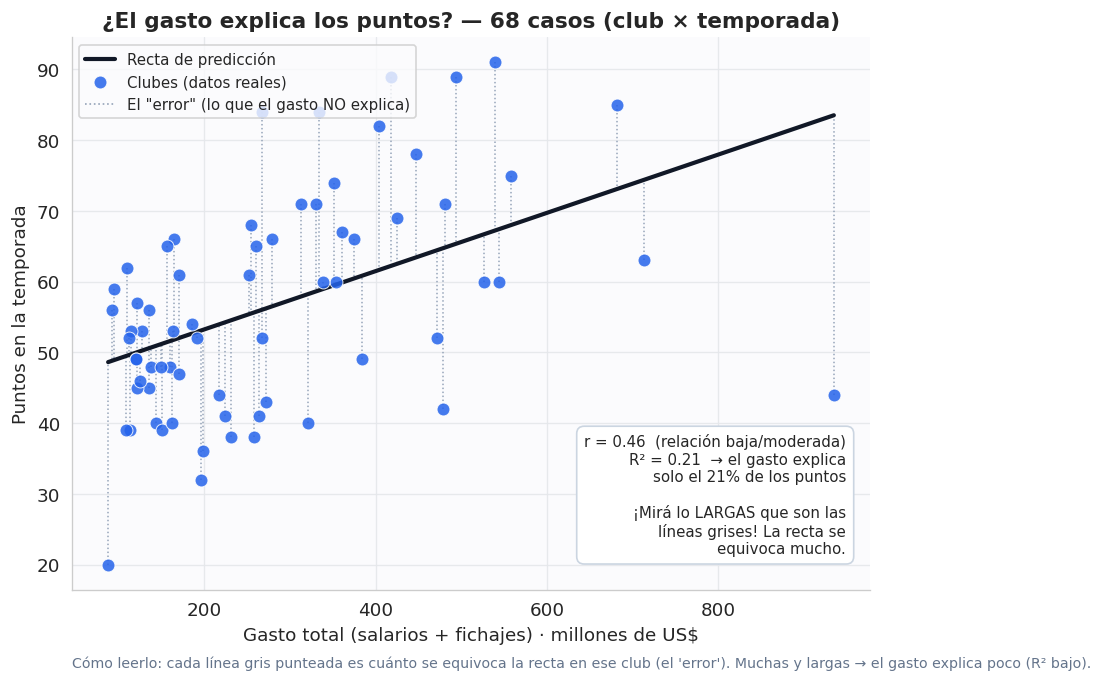

r=0.46 | R²=0.21 | cada +100 M$ ~ +4.1 puntos


In [28]:
X = panel["Gasto_Total_M"].values; Y = panel["Puntos"].values
b1, b0 = np.polyfit(X, Y, 1); Yhat = b0 + b1*X
rr = np.corrcoef(X, Y)[0,1]

fig, ax = plt.subplots(figsize=(9,5.8))
# 1) líneas de "error" (residuos): de cada punto a la recta -> hacen VISIBLE el R²
for xi, yi, yh in zip(X, Y, Yhat):
    ax.plot([xi, xi], [yi, yh], color="#94a3b8", lw=0.9, ls=":", zorder=1)
# 2) recta de predicción
xs = np.linspace(X.min(), X.max(), 100)
ax.plot(xs, b0+b1*xs, color="#111827", lw=2.5, zorder=2, label="Recta de predicción")
# 3) puntos reales
ax.scatter(X, Y, s=60, c=AZUL, alpha=0.85, edgecolor="white", linewidth=0.6, zorder=3, label="Clubes (datos reales)")
ax.plot([], [], color="#94a3b8", lw=1, ls=":", label='El "error" (lo que el gasto NO explica)')
ax.text(0.97, 0.06,
        f"r = {rr:.2f}  (relación baja/moderada)\nR² = {rr**2:.2f}  → el gasto explica\nsolo el {rr**2*100:.0f}% de los puntos\n\n¡Mirá lo LARGAS que son las\nlíneas grises! La recta se\nequivoca mucho.",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#cbd5e1"))
ax.set_title("¿El gasto explica los puntos? — 68 casos (club × temporada)")
ax.set_xlabel("Gasto total (salarios + fichajes) · millones de US$")
ax.set_ylabel("Puntos en la temporada"); ax.legend(loc="upper left", fontsize=9)
ax.text(0,-0.14,"Cómo leerlo: cada línea gris punteada es cuánto se equivoca la recta en ese club (el 'error'). "
        "Muchas y largas → el gasto explica poco (R² bajo).", transform=ax.transAxes, fontsize=8.5, color=GRIS)
plt.tight_layout(); plt.savefig("figuras/g4_gasto_vs_puntos.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"r={rr:.2f} | R²={rr**2:.2f} | cada +100 M$ ~ +{b1*100:.1f} puntos")

**Interpretación.** La relación es **positiva pero débil**: `r ≈ 0,46` y `R² ≈ 0,21`, es decir que el
gasto explica solo **~1/5** de las diferencias de puntos. La nube está muy desparramada alrededor de la
recta; gastar ayuda en promedio, pero **deja la mayor parte sin explicar** — hay mucho margen para la
gestión (y algo de suerte). En la sección 5 vemos que, además, esa relación **no es infinita**: tiene un
punto óptimo a partir del cual gastar más rinde negativo.

### 4.e) El mapa de la eficiencia  *(tipo cuadrantes, promedio 4 temporadas)*

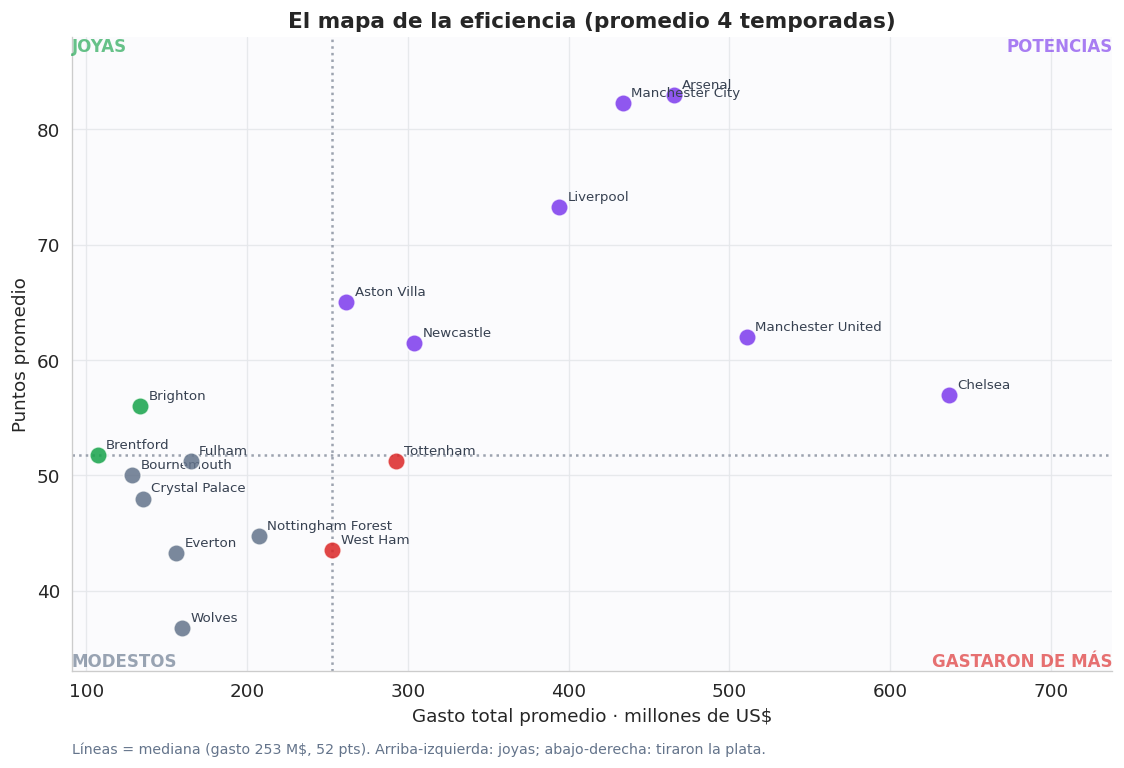

In [29]:
# [IA] Prompt: "Scatter de cuadrantes por mediana de gasto y puntos, etiquetando clubes y coloreando por cuadrante."
mg, mp = clubes["Gasto"].median(), clubes["Puntos"].median()
def cuad(g,p):
    if g>=mg and p>=mp: return VIOLETA
    if g< mg and p>=mp: return VERDE
    if g>=mg and p< mp: return ROJO
    return GRIS
fig, ax = plt.subplots(figsize=(9.5,6.5))
for _, r in clubes.iterrows():
    ax.scatter(r["Gasto"], r["Puntos"], s=110, c=cuad(r["Gasto"],r["Puntos"]), alpha=0.85, edgecolor="white", zorder=3)
    ax.annotate(r["Club"].title(), (r["Gasto"], r["Puntos"]), xytext=(5,4), textcoords="offset points", fontsize=8, color="#374151")
ax.axvline(mg, color="#9ca3af", ls=":", lw=1.5); ax.axhline(mp, color="#9ca3af", ls=":", lw=1.5)
xmin,xmax = clubes["Gasto"].min()*0.85, clubes["Gasto"].max()*1.16
ymin,ymax = clubes["Puntos"].min()*0.9, clubes["Puntos"].max()*1.06
for tx,ty,txt,col,ha,va in [(xmax,ymax,"POTENCIAS",VIOLETA,"right","top"),(xmin,ymax,"JOYAS",VERDE,"left","top"),
                            (xmax,ymin,"GASTARON DE MÁS",ROJO,"right","bottom"),(xmin,ymin,"MODESTOS",GRIS,"left","bottom")]:
    ax.text(tx,ty,txt,ha=ha,va=va,fontsize=10,color=col,weight="bold",alpha=0.65)
ax.set_xlim(xmin,xmax); ax.set_ylim(ymin,ymax)
ax.set_title("El mapa de la eficiencia (promedio 4 temporadas)")
ax.set_xlabel("Gasto total promedio · millones de US$"); ax.set_ylabel("Puntos promedio")
ax.text(0,-0.13,f"Líneas = mediana (gasto {mg:.0f} M$, {mp:.0f} pts). Arriba-izquierda: joyas; abajo-derecha: tiraron la plata.",
        transform=ax.transAxes, fontsize=8.5, color=GRIS)
plt.tight_layout(); plt.savefig("figuras/g5_cuadrantes.png", dpi=150, bbox_inches="tight"); plt.show()

**Interpretación.** **Brighton, Bournemouth y Brentford** son las **joyas** (poco gasto, buen
rendimiento); **City, Liverpool, Arsenal** son las **potencias** que pagan y ganan; y los carísimos
**Chelsea** y **Manchester United** quedan muy a la derecha, delatando cuánto pagaron por quedarse en la
media. Abajo-izquierda, los clubes modestos que cumplen sin gastar.

## 5. Aplicación de conceptos de la materia  *(consigna 3.5)*
Núcleo en **elasticidad** (función documentada), más **estructura del gasto (salarios vs fichajes)**,
**función de costo / rendimientos decrecientes** y **margen/rentabilidad**.

### 5.1) Función documentada: elasticidad-arco

In [30]:
# [IA] Prompt: "Función documentada de elasticidad-arco de Y respecto de X y otra que la clasifique."
def elasticidad_arco(x_ini, x_fin, y_ini, y_fin):
    '''Elasticidad-arco de Y respecto de X entre dos períodos (fórmula del punto medio):
        E = (%Δ Y)/(%Δ X), con %Δ V = (V_fin-V_ini)/((V_fin+V_ini)/2).
    >1 elástica, <1 inelástica, negativa = relación inversa, NaN si X no varía.'''
    vx = (x_fin-x_ini)/((x_fin+x_ini)/2); vy = (y_fin-y_ini)/((y_fin+y_ini)/2)
    return np.nan if vx==0 else vy/vx

def clasificar_elasticidad(e):
    '''Clasifica la elasticidad en categorías económicas.'''
    if pd.isna(e): return "indefinida"
    if e<0: return "inversa (gastó más, rindió menos)"
    if abs(e)>1: return "elástica"
    if abs(e)==1: return "unitaria"
    return "inelástica"

### 5.2) Aplicación: elasticidad puntos–gasto entre la primera y la última temporada (22/23 → 25/26)

In [31]:
piv = panel.pivot_table(index="Club", columns="Temporada", values=["Gasto_Total_M","Puntos"])
res = []
for club in piv.index:
    e = elasticidad_arco(piv.loc[club,("Gasto_Total_M","22/23")], piv.loc[club,("Gasto_Total_M","25/26")],
                         piv.loc[club,("Puntos","22/23")], piv.loc[club,("Puntos","25/26")])
    res.append({"Club":club.title(),"Elasticidad":e,"Tipo":clasificar_elasticidad(e)})
tabE = pd.DataFrame(res).sort_values("Elasticidad", ascending=False).round(2)
display(tabE.reset_index(drop=True))
elast_glob,_ = np.polyfit(np.log(panel["Gasto_Total_M"]), np.log(panel["Puntos"]), 1)
print(f"Elasticidad global (log-log sobre el panel, n=68): {elast_glob:.2f} -> {clasificar_elasticidad(elast_glob)}")

,Club,Elasticidad,Tipo
0,Bournemouth,3.30,elástica
1,Aston Villa,1.85,elástica
2,Tottenham,0.93,inelástica
3,Wolves,0.69,inelástica
4,Manchester United,0.37,inelástica
5,West Ham,0.04,inelástica
6,Arsenal,0.02,inelástica
7,Fulham,-0.00,inelástica
8,Crystal Palace,-0.00,inelástica
9,Chelsea,-0.25,"inversa (gastó más, rindió menos)"


Elasticidad global (log-log sobre el panel, n=68): 0.24 -> inelástica


**Interpretación (elasticidad).** A nivel panel la elasticidad puntos–gasto es **~0,24: muy
inelástica** (subir el gasto 10% se asocia con ~2,4% más de puntos). Caso a caso hay de todo, incluso
**elasticidades negativas** (clubes que gastaron más y rindieron menos). Consistente con la teoría:
cuando una variable es inelástica, mover el "precio" (gasto) cambia poco la "cantidad" (puntos).

### 5.3) Estructura del gasto: ¿salarios o fichajes? (efecto Szymanski)
La economía del deporte (Szymanski) sostiene que **la masa salarial predice el rendimiento mejor que
los fichajes**. Lo testeamos en nuestro panel.

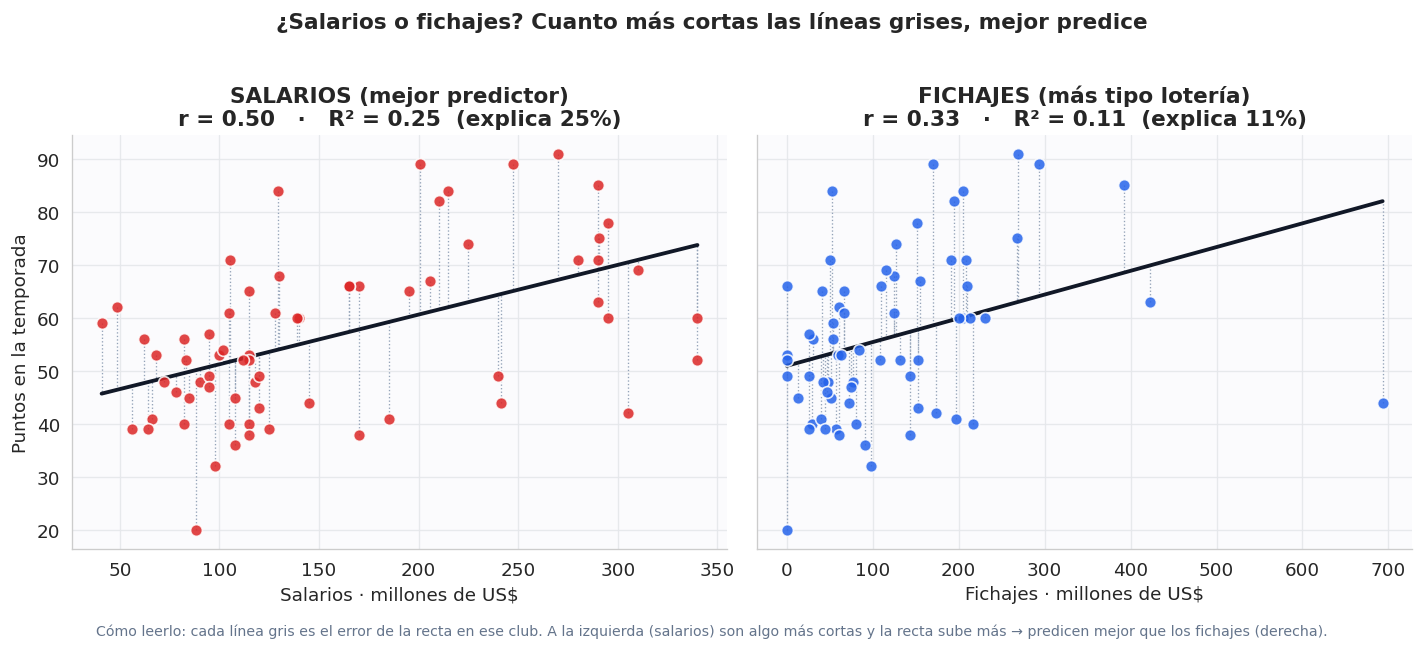

Correlación con puntos -> SALARIOS: 0.50 (R²=0.25)  |  FICHAJES: 0.33 (R²=0.11)


In [32]:
# [IA] Prompt: "Comparación didáctica: dos paneles (salarios vs fichajes) con líneas de error (residuos)
#               para VER que los salarios predicen mejor (líneas más cortas) que los fichajes."
r_sal = np.corrcoef(panel["Salarios_M"], panel["Puntos"])[0,1]
r_fic = np.corrcoef(panel["Fichajes_M"], panel["Puntos"])[0,1]
fig, axes = plt.subplots(1,2, figsize=(12,5), sharey=True)
config = [("Salarios_M", ROJO, "SALARIOS (mejor predictor)", r_sal),
          ("Fichajes_M", AZUL, "FICHAJES (más tipo lotería)", r_fic)]
for ax,(xv,col,lab,rv) in zip(axes, config):
    X = panel[xv].values; Y = panel["Puntos"].values
    b1,b0 = np.polyfit(X, Y, 1); Yhat = b0+b1*X
    for xi,yi,yh in zip(X,Y,Yhat):                      # líneas de error (residuos)
        ax.plot([xi,xi],[yi,yh], color="#94a3b8", lw=0.8, ls=":", zorder=1)
    xs=np.linspace(X.min(),X.max(),50); ax.plot(xs,b0+b1*xs,color="#111827",lw=2.3, zorder=2)
    ax.scatter(X, Y, c=col, s=50, alpha=0.85, edgecolor="white", zorder=3)
    ax.set_title(f"{lab}\nr = {rv:.2f}   ·   R² = {rv**2:.2f}  (explica {rv**2*100:.0f}%)")
    ax.set_xlabel(xv.replace('_M',' · millones de US$'))
axes[0].set_ylabel("Puntos en la temporada")
plt.suptitle("¿Salarios o fichajes? Cuanto más cortas las líneas grises, mejor predice", y=1.02, fontsize=13, weight="bold")
fig.text(0.5, -0.02, "Cómo leerlo: cada línea gris es el error de la recta en ese club. A la izquierda (salarios) son algo "
         "más cortas y la recta sube más → predicen mejor que los fichajes (derecha).", ha="center", fontsize=8.5, color=GRIS)
plt.tight_layout(); plt.savefig("figuras/g6_salarios_vs_fichajes.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"Correlación con puntos -> SALARIOS: {r_sal:.2f} (R²={r_sal**2:.2f})  |  FICHAJES: {r_fic:.2f} (R²={r_fic**2:.2f})")

###**Interpretación**
Tal como predice la teoría, **los salarios se asocian más fuerte con
los puntos (r ≈ 0,50) que los fichajes (r ≈ 0,34)**. Tiene lógica: el salario refleja la calidad
*sostenida* del plantel, mientras que el gasto en fichajes es más errático (un año se compra mucho, otro
poco). Para gestionar rendimiento, *quién está en nómina* importa más que *cuánto se gastó en el último mercado*.



### 5.4) ¿Hasta dónde conviene gastar? Óptimo y rendimientos decrecientes (con `sympy`)
En lugar de una recta, ajustamos con `numpy` una **parábola** `Puntos = a + b·Gasto + c·Gasto²`, que sí
puede capturar un punto de saturación. Con `sympy` calculamos la **1ª derivada** (para hallar el gasto
óptimo, donde se hace cero) y la **2ª derivada** (para confirmar, por su signo, que es un máximo).

Función ajustada (numpy):  Puntos = 31.10 + 0.1385·g + -0.000124·g²
1ra derivada  f'(g)  = 0.138529984378844 - 0.000247288409447472*g    (puntos por millón adicional)
2da derivada  f''(g) = -0.000247288409447472   = -0.000247  < 0  ->  cóncava: el óptimo es un MÁXIMO

>> GASTO ÓPTIMO ≈ 560 M$  ->  máximo ~70 puntos
>> Marginal: en 150 M$ = +0.101 pts/M$ | en 400 M$ = +0.040 | en 560 M$ ≈ 0
>> A partir de ~560 M$ la curva baja: gastar más se asocia con MENOS puntos (sobreinversión).


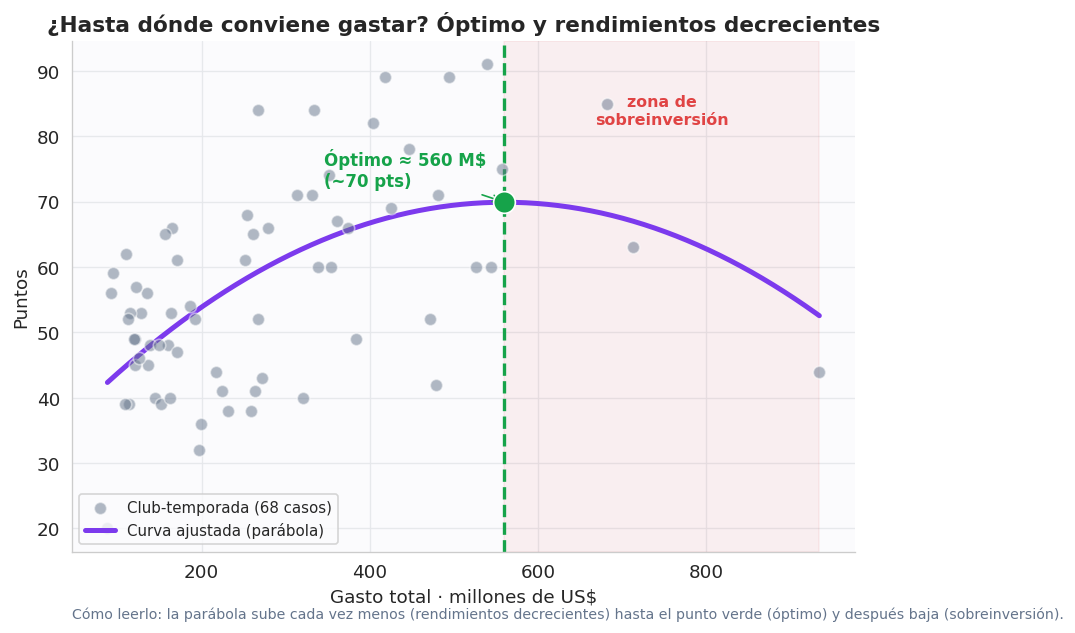

In [33]:
# [IA] Prompt: "Ajustá una parábola puntos~gasto con numpy; con sympy obtené 1ra y 2da derivada, hallá
#               el gasto óptimo (f'=0) y confirmá con la 2da derivada que es un máximo; graficá el óptimo."
G = panel["Gasto_Total_M"].values; P = panel["Puntos"].values
c2, c1, c0 = np.polyfit(G, P, 2)                       # numpy: ajuste cuadrático

g = sp.symbols("g", positive=True)
f  = c0 + c1*g + c2*g**2                               # sympy: Puntos(Gasto)
f1 = sp.diff(f, g)                                     # 1ra derivada = puntos por M$ adicional
f2 = sp.diff(f, g, 2)                                  # 2da derivada = curvatura
g_opt = float(sp.solve(sp.Eq(f1, 0), g)[0])           # gasto óptimo: f'(g)=0
p_opt = float(f.subs(g, g_opt))

print(f"Función ajustada (numpy):  Puntos = {c0:.2f} + {c1:.4f}·g + {c2:.6f}·g²")
print("1ra derivada  f'(g)  =", f1, "   (puntos por millón adicional)")
print("2da derivada  f''(g) =", f2, f"  = {float(f2):.6f}  < 0  ->  cóncava: el óptimo es un MÁXIMO")
print(f"\n>> GASTO ÓPTIMO ≈ {g_opt:.0f} M$  ->  máximo ~{p_opt:.0f} puntos")
print(f">> Marginal: en 150 M$ = +{float(f1.subs(g,150)):.3f} pts/M$ | en 400 M$ = +{float(f1.subs(g,400)):.3f} | en {g_opt:.0f} M$ ≈ 0")
print(f">> A partir de ~{g_opt:.0f} M$ la curva baja: gastar más se asocia con MENOS puntos (sobreinversión).")

fig, ax = plt.subplots(figsize=(8.8,5.4))
ax.scatter(G, P, s=55, c=GRIS, alpha=0.5, edgecolor="white", zorder=3, label="Club-temporada (68 casos)")
xs = np.linspace(G.min(), G.max(), 200)
ax.plot(xs, c0+c1*xs+c2*xs**2, color=VIOLETA, lw=3, zorder=2, label="Curva ajustada (parábola)")
ax.axvspan(g_opt, G.max(), color=ROJO, alpha=0.06)
ax.axvline(g_opt, color=VERDE, ls="--", lw=2)
ax.scatter([g_opt], [p_opt], s=170, c=VERDE, zorder=5, edgecolor="white")
ax.annotate(f"Óptimo ≈ {g_opt:.0f} M$\n(~{p_opt:.0f} pts)", (g_opt, p_opt), xytext=(g_opt-215, p_opt+2.5),
            fontsize=10, weight="bold", color=VERDE, arrowprops=dict(arrowstyle="->", color=VERDE))
ax.text(g_opt+(G.max()-g_opt)/2, p_opt+12, "zona de\nsobreinversión", ha="center", color=ROJO, fontsize=9.5, weight="bold", alpha=0.85)
ax.set_title("¿Hasta dónde conviene gastar? Óptimo y rendimientos decrecientes")
ax.set_xlabel("Gasto total · millones de US$"); ax.set_ylabel("Puntos"); ax.legend(loc="lower left", fontsize=9)
ax.text(0,-0.13,"Cómo leerlo: la parábola sube cada vez menos (rendimientos decrecientes) hasta el punto verde "
        "(óptimo) y después baja (sobreinversión).", transform=ax.transAxes, fontsize=8.5, color=GRIS)
plt.tight_layout(); plt.savefig("figuras/g7_optimo_gasto.png", dpi=150, bbox_inches="tight"); plt.show()

**Interpretación (óptimo y 2ª derivada).** La **1ª derivada `f'(g)`** es el *producto marginal del
dinero* (cuántos puntos suma el próximo millón): empieza alta y **va cayendo** — eso son los rendimientos
decrecientes. Se hace **cero en g\* ≈ 560 M$**, el **gasto óptimo**, donde los puntos se maximizan (~70).
La **2ª derivada `f''(g)` es negativa y constante (≈ 0,00025)**: confirma que la curva es **cóncava**, o
sea que el punto crítico es un **máximo** (no un mínimo) y que los rendimientos decrecen en todo el tramo.
Pasado el óptimo, gastar más se asocia con **menos** puntos; en los datos el único club en esa zona es
**Chelsea (640 M)** — la marca de la *sobreinversión*. **Moraleja:** el dinero rinde hasta un techo; de
ahí en más, lo que falta es gestión.

### Optimización del presupuesto con programación lineal (`pulp`)
Pregunta de gestión: con un presupuesto fijo, ¿cuánto poner en **salarios** y cuánto en **fichajes**?
Lo resolvemos como **programación lineal**: maximizar los puntos esperados según la regresión múltiple
`Puntos ≈ β_sal·Salarios + β_fic·Fichajes`, exigiendo invertir algo en ambos (mínimo 15% en fichajes,
máximo 90% en salarios).

In [34]:
# [IA] Prompt: "Con pulp, repartí un presupuesto fijo entre salarios y fichajes para maximizar los puntos
#               esperados usando los coeficientes de una regresión múltiple; mostrá la asignación óptima."
# Coeficientes de Puntos ~ Salarios + Fichajes (numpy)
Xm = np.column_stack([panel["Salarios_M"], panel["Fichajes_M"], np.ones(len(panel))])
beta_sal, beta_fic, intercepto = np.linalg.lstsq(Xm, panel["Puntos"].values, rcond=None)[0]
print(f"Aporte estimado por M$ -> salarios: {beta_sal:.4f} pts | fichajes: {beta_fic:.4f} pts")

PRES = 300  # presupuesto a repartir (M$), valor de ejemplo
prob = pulp.LpProblem("asignacion_presupuesto", pulp.LpMaximize)
S = pulp.LpVariable("Salarios", lowBound=0)
F = pulp.LpVariable("Fichajes", lowBound=0)
prob += beta_sal*S + beta_fic*F          # objetivo: puntos esperados
prob += S + F <= PRES                     # restricción de presupuesto
prob += F >= 0.15*PRES                    # hay que invertir algo en fichajes
prob += S <= 0.90*PRES                    # no todo puede ir a salarios
prob.solve(pulp.PULP_CBC_CMD(msg=0))
pts_esp = intercepto + beta_sal*S.value() + beta_fic*F.value()
print(f"\nPresupuesto = {PRES} M$  ->  asignación óptima ({pulp.LpStatus[prob.status]}):")
print(f"  Salarios: {S.value():.0f} M$  ({S.value()/PRES*100:.0f}%)")
print(f"  Fichajes: {F.value():.0f} M$  ({F.value()/PRES*100:.0f}%)")
print(f"  Puntos esperados: {pts_esp:.1f}")

Aporte estimado por M$ -> salarios: 0.0841 pts | fichajes: 0.0134 pts

Presupuesto = 300 M$  ->  asignación óptima (Optimal):
  Salarios: 255 M$  (85%)
  Fichajes: 45 M$  (15%)
  Puntos esperados: 63.8


**Interpretación (`pulp`).** Como cada millón en **salarios** aporta más puntos que en fichajes, la
solución óptima **carga el presupuesto al máximo en salarios y deja el mínimo en fichajes (≈ 85% / 15%)**.
Es el efecto Szymanski traducido a una decisión de gestión: ante un peso disponible, *conviene sostener un
buen plantel en nómina antes que apostar al golpe de mercado*. Es un modelo ilustrativo y lineal —en la
realidad hay topes salariales, fair-play financiero y los rendimientos decrecientes que vimos arriba que
lo matizan.

### 5.5) Margen, rentabilidad y objetivo deportivo
Clasificamos a los 17 por **objetivo**, usando sus **puntos promedio** de las 4 temporadas:
**Pelea arriba** (≥65), **Media tabla / Europa** (50–64) y **Lucha por permanecer** (<50).

,clubes,gasto_prom,puntos_prom,costo_punto
Objetivo,,,,
Pelea arriba,4,388.8,75.9,5.1
Media tabla / Europa,8,284.7,55.1,5.0
Lucha por permanecer,5,182.2,43.2,4.2


  Pelea arriba: Arsenal, Aston Villa, Liverpool, Manchester City
  Media tabla / Europa: Bournemouth, Brentford, Brighton, Chelsea, Fulham, Manchester United, Newcastle, Tottenham
  Lucha por permanecer: Crystal Palace, Everton, Nottingham Forest, West Ham, Wolves


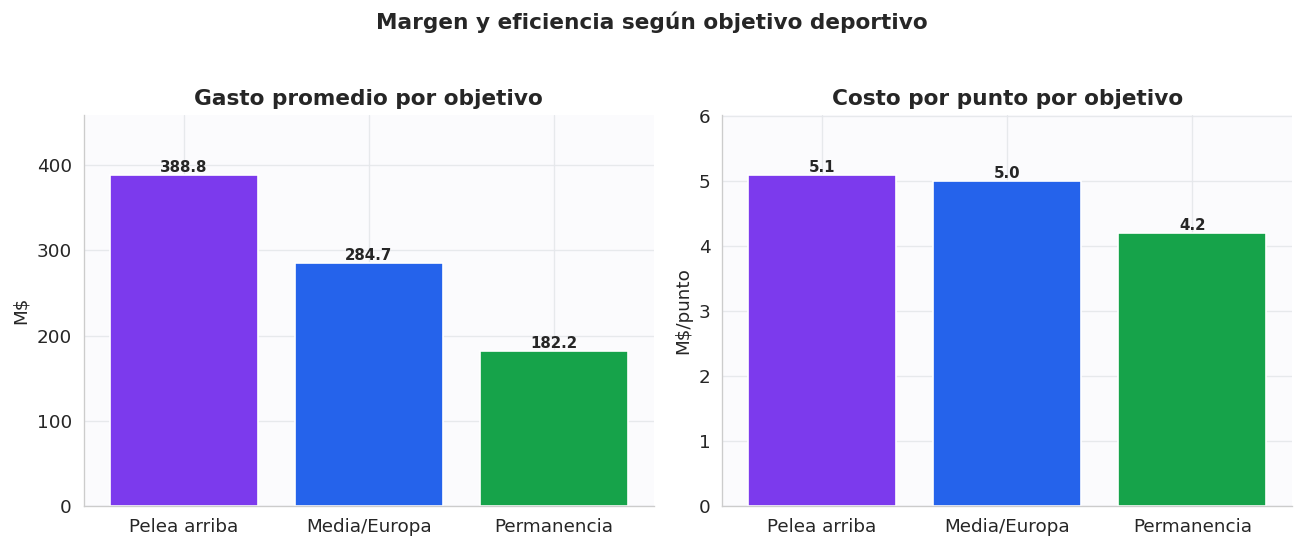


Más rentables (puntos por millón):


,Club,Gasto,Puntos,Puntos_por_M
0,BRENTFORD,107.08,51.75,0.48
1,BRIGHTON,133.59,56.00,0.42
2,BOURNEMOUTH,128.70,50.00,0.39
3,CRYSTAL PALACE,135.32,48.00,0.35
4,FULHAM,165.05,51.25,0.31


In [35]:
def objetivo(pts_prom):
    '''Objetivo deportivo según puntos promedio de las 4 temporadas.'''
    if pts_prom >= 65: return "Pelea arriba"
    if pts_prom >= 50: return "Media tabla / Europa"
    return "Lucha por permanecer"
clubes["Objetivo"] = clubes["Puntos"].apply(objetivo)
orden_o = ["Pelea arriba","Media tabla / Europa","Lucha por permanecer"]
res_o = (clubes.groupby("Objetivo").agg(clubes=("Club","count"), gasto_prom=("Gasto","mean"),
         puntos_prom=("Puntos","mean"), costo_punto=("Costo_por_punto","mean")).reindex(orden_o).round(1))
display(res_o)
for o in orden_o: print(f"  {o}: " + ", ".join(clubes.loc[clubes['Objetivo']==o,'Club'].str.title()))

fig, axes = plt.subplots(1,2, figsize=(11,4.4)); cols=[VIOLETA,AZUL,VERDE]; lab=["Pelea arriba","Media/Europa","Permanencia"]
for ax,(ti,se,yl) in zip(axes,[("Gasto promedio por objetivo",res_o["gasto_prom"],"M$"),
                                ("Costo por punto por objetivo",res_o["costo_punto"],"M$/punto")]):
    bars=ax.bar(range(3), se, color=cols, edgecolor="white")
    for r,v in zip(bars,se): ax.text(r.get_x()+r.get_width()/2, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9, weight="bold")
    ax.set_title(ti); ax.set_ylabel(yl); ax.set_xticks(range(3)); ax.set_xticklabels(lab); ax.set_ylim(0, se.max()*1.18)
plt.suptitle("Margen y eficiencia según objetivo deportivo", y=1.03, fontsize=13, weight="bold")
plt.tight_layout(); plt.savefig("figuras/g8_objetivo.png", dpi=150, bbox_inches="tight"); plt.show()

clubes["Participacion_%"] = 100*clubes["Gasto"]/clubes["Gasto"].sum()
print("\nMás rentables (puntos por millón):")
display(clubes.sort_values("Puntos_por_M", ascending=False)[["Club","Gasto","Puntos","Puntos_por_M"]].head(5).round(2).reset_index(drop=True))

**Interpretación (margen/objetivo).** Curiosamente, el costo por punto es **parejo entre la pelea de
arriba (5,1) y la zona media (~5,2)**, y hasta **más barato en la lucha por permanecer (~4,2)**: los
clubes chicos no se pueden dar el lujo de derrochar, así que cada peso rinde. Medido como **puntos por
millón**, los más rentables son los de presupuesto chico (**Brentford, Bournemouth, Brighton**). El
gasto está, además, muy concentrado en pocos clubes.

## 6. La trampa de los ascendidos

El dato más llamativo del período: en **2023/24 y 2024/25 los tres equipos ascendidos descendieron**
(seis equipos seguidos volvieron a Segunda al primer intento), dejando intacto el núcleo de 17. ¿Por qué?
Comparamos el gasto de los clubes que **descendieron** (con datos en 21/22 y 22/23) contra los 17 estables.

Clubes que terminaron descendiendo (datos disponibles):


,Club,Temp,Gasto,Puntos
0,Burnley,21,102.0,35.0
1,Leeds,21,94.0,38.0
2,Leeds,22/23,243.0,31.0
3,Leicester,21,165.0,52.0
4,Leicester,22/23,154.0,34.0
5,Norwich,21,108.0,22.0
6,Southampton,21,134.0,40.0
7,Southampton,22/23,233.0,25.0
8,Watford,21,98.0,23.0


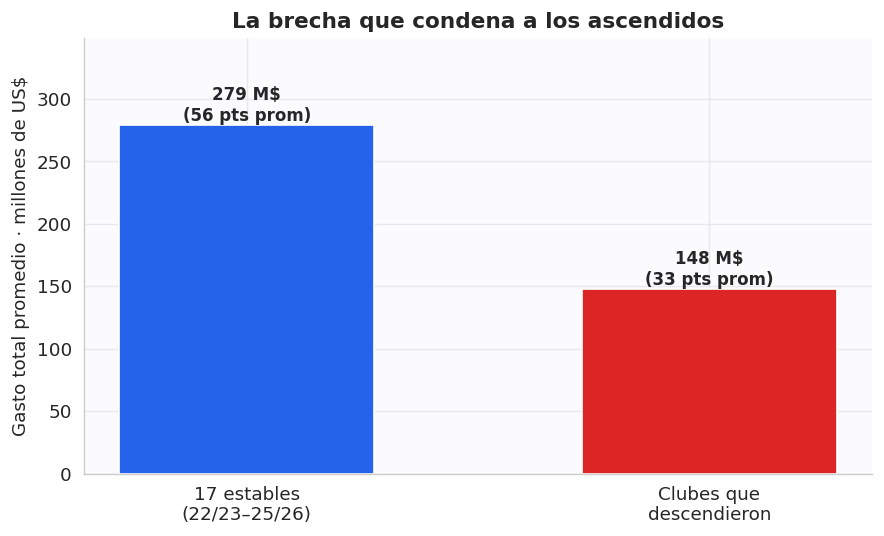


Los estables gastan ~1.9x más que los que descienden.


In [36]:
# [IA] Prompt: "Compará el gasto promedio de los clubes que descendieron vs los 17 estables para ilustrar la brecha."
desc = ["BURNLEY","LEEDS","LEICESTER","SOUTHAMPTON","NORWICH","WATFORD"]
filas_d = []
for _, r in maestro[maestro["CLUBES"].isin(desc)].iterrows():
    for yr in ["21","22"]:
        pt = pd.to_numeric(pd.Series([r[f"PUNTOS_{yr}"]]), errors="coerce").iloc[0]
        if pt and pt>0:
            sal = parsear_dinero(pd.Series([r[f"SALARIOS_AÑO_{yr}"]])).iloc[0]/1e6
            fic = pd.to_numeric(pd.Series([r[f"GASTOS_FICHAJES_{yr}_M$"]]), errors="coerce").iloc[0]
            filas_d.append({"Club":r["CLUBES"].title(),"Temp":SEAS.get(yr,yr),"Gasto":sal+fic,"Puntos":pt})
descendidos = pd.DataFrame(filas_d)
print("Clubes que terminaron descendiendo (datos disponibles):"); display(descendidos.round(0))

g_estables = panel["Gasto_Total_M"].mean(); p_estables = panel["Puntos"].mean()
g_desc = descendidos["Gasto"].mean(); p_desc = descendidos["Puntos"].mean()
fig, ax = plt.subplots(figsize=(7.5,4.6))
bars = ax.bar(["17 estables\n(22/23–25/26)","Clubes que\ndescendieron"], [g_estables, g_desc],
              color=[AZUL, ROJO], edgecolor="white", width=0.55)
for r,v,pt in zip(bars,[g_estables,g_desc],[p_estables,p_desc]):
    ax.text(r.get_x()+r.get_width()/2, v, f"{v:.0f} M$\n({pt:.0f} pts prom)", ha="center", va="bottom", fontsize=10, weight="bold")
ax.set_title("La brecha que condena a los ascendidos")
ax.set_ylabel("Gasto total promedio · millones de US$"); ax.set_ylim(0, g_estables*1.25)
plt.tight_layout(); plt.savefig("figuras/g9_trampa_ascendidos.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"\nLos estables gastan ~{g_estables/g_desc:.1f}x más que los que descienden.")

**Interpretación.** La brecha es brutal: los 17 estables gastan en promedio **280 M** y suman 56
puntos, mientras los clubes que terminaron descendiendo gastaron **148 M** (la mitad) y promediaron
**~33 puntos**. Y el detalle más interesante: **gastar más tampoco los salvó** — Leeds (243 M) y
Southampton (233 M) hicieron grandes desembolsos para sobrevivir en 22/23 y **igual descendieron**. La
*trampa de los ascendidos* es estructural: llegan con un plantel y unas estructuras muy por debajo del
piso de la Premier, y un mercado de pánico rara vez alcanza para cerrar esa distancia en una temporada.
Por eso en 23/24 y 24/25 los seis ascendidos volvieron a bajar.

## 7. Descubrimientos y datos curiosos

In [37]:
def top_col(sheet, col):
    e = pd.read_excel(xls, sheet); v = pd.to_numeric(e[col], errors="coerce")
    i = v.idxmax(); return e.loc[i,"Jugador"], v.loc[i]
big = compras.loc[compras["Coste_M$"].idxmax()]
posc = compras.groupby("Posición")["Coste_M$"].mean().sort_values(ascending=False)
gast = compras.groupby("Club_Involucrado")["Coste_M$"].sum().sort_values(ascending=False)
ga_j, ga_v = top_col("ESTADISTICAS_21","goalsAssistsSum"); rt_j, rt_v = top_col("ESTADISTICAS_21","rating")
print("⚽ DATOS CURIOSOS — Premier 21/22 → 25/26"); print("-"*60)
print(f"💰 Fichaje más caro (5 temp): {big['Jugador']} → {big['Club_Involucrado'].title()} ({big['Coste_M$']:.0f} M$, {big['Temporada']})")
print(f"🎯 Posición más cara:        {posc.index[0]} ({posc.iloc[0]:.0f} M$)  |  más barata: {posc.index[-1]} ({posc.iloc[-1]:.0f} M$)")
print(f"🛒 Club más gastador:        {gast.index[0].title()} ({gast.iloc[0]:.0f} M$ en fichajes)")
print(f"📈 Total compras 5 temp:     {len(compras)} operaciones por {compras['Coste_M$'].sum():.0f} M$")
print(f"🏅 Más eficiente (4 temp):   {clubes.loc[clubes['Costo_por_punto'].idxmin(),'Club'].title()} ({clubes['Costo_por_punto'].min():.1f} M$/punto)")
print(f"🐌 Menos eficiente:          {clubes.loc[clubes['Costo_por_punto'].idxmax(),'Club'].title()} ({clubes['Costo_por_punto'].max():.1f} M$/punto)")
print("\nFichaje más caro por temporada:")
for t in ["21/22","22/23","23/24","24/25","25/26"]:
    s = compras[compras["Temporada"]==t]
    if len(s):
        b = s.loc[s["Coste_M$"].idxmax()]; print(f"  {t}: {b['Jugador']} ({b['Coste_M$']:.0f} M$, {b['Club_Involucrado'].title()})")

⚽ DATOS CURIOSOS — Premier 21/22 → 25/26
------------------------------------------------------------
💰 Fichaje más caro (5 temp): Alexander Isak → Liverpool Fc (165 M$, 25/26)
🎯 Posición más cara:        Delantero centro (42 M$)  |  más barata: Portero (20 M$)
🛒 Club más gastador:        Chelsea (1348 M$ en fichajes)
📈 Total compras 5 temp:     295 operaciones por 9261 M$
🏅 Más eficiente (4 temp):   Brentford (2.1 M$/punto)
🐌 Menos eficiente:          Chelsea (11.2 M$/punto)

Fichaje más caro por temporada:
  21/22: Ben White (64 M$, Arsenal)
  22/23: Enzo Fernández (133 M$, Chelsea)
  23/24: Declan Rice (133 M$, Arsenal)
  24/25: Pedro Neto (69 M$, Chelsea)
  25/26: Alexander Isak (165 M$, Liverpool Fc)


**Lo más jugoso.** El récord del período es **Alexander Isak (~165 M$)**. Los **delanteros centro** son
la posición más cara y los **arqueros** la más barata. **Chelsea** lideró el gasto en fichajes. Y aunque
la base es financiera, los nombres aparecen: **Salah** dominó goles+asistencias y **De Bruyne** el mejor
rating de 21/22.

---
## 9. Conclusiones

### 9.1) Síntesis de los hallazgos
1. **El dinero ayuda pero no compra puntos.** En el panel de 68 casos, el gasto explica solo ~1/5 del
   rendimiento (R² ≈ 0,22) y la elasticidad es **inelástica (0,24)**.
2. **Los salarios pesan más que los fichajes** (r ≈ 0,50 vs 0,34): la calidad *sostenida* del plantel
   predice mejor que el último mercado (efecto Szymanski).
3. **Inflación sin resultados.** La masa salarial de los 17 creció **+43%** en cuatro temporadas con
   puntos planos: el "precio del punto" sube.
4. **La eficiencia manda.** Costo por punto de ~2,1 M (Brentford) a ~11,2M(Chelsea). El ajuste
   cuadrático muestra rendimientos decrecientes con un **óptimo de gasto ≈ 560 M** (2ª derivada negativa
   → es un máximo): más allá de ese punto, gastar más se asocia con *menos* puntos (zona Chelsea).
5. **La trampa de los ascendidos.** Los que descienden gastan la mitad (~148 vs ~280 M$) y, aun cuando
   se estiran (Leeds, Southampton), igual bajan: en 23/24 y 24/25 los seis ascendidos volvieron a Segunda.
6. **Por objetivo,** el costo por punto es parejo arriba y en el medio, y más barato entre los que pelean
   por no descender (no pueden derrochar).

### 9.2) Limitaciones
-  Una sola liga;
- los stats por jugador solo cubren 21/22–22/23 y tienen esquema irregular, por lo
que el foco fue el nivel club;
- sin variables de control, las medidas son descriptivas, no causales;
- de los clubes ascendidos solo hay datos de algunos (los del período 21/22–22/23).

### 9.3) Extensiones posibles
Sumar **valores de mercado de Transfermarkt** por jugador para medir rentabilidad individual; modelar el
panel con efectos fijos por club/temporada; incorporar datos de los ascendidos recientes.

### 9.4) Conclusión objetiva
> Sobre la base analizada (Premier League, 17 clubes en 4 temporadas, 2022/23–2025/26), **no se verifica
> que un mayor gasto determine un mejor rendimiento deportivo**: la asociación gasto–puntos es débil
> (R² ≈ 0,22) e inelástica (~0,24), con rendimientos marginales decrecientes.

> Entre los componentes del
> gasto, **los salarios predicen el rendimiento mejor que los fichajes**, y el costo del punto creció por
> la inflación salarial sin mejora en los resultados. La variable que mejor distingue a los clubes es su
> **eficiencia**, no el volumen de gasto. Finalmente, la **brecha financiera estructural** entre el núcleo
> estable y los ascendidos explica por qué estos últimos descienden de forma recurrente. Los resultados
> son consistentes con la literatura económica del deporte y se presentan como descriptivos.